In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore")


In [90]:
pip install plotly geopandas


   ---------------------------------------- 0.0/22.9 MB ? eta -:--:--
   ---------- ----------------------------- 6.3/22.9 MB 32.2 MB/s eta 0:00:01
   ------------------ --------------------- 10.7/22.9 MB 25.8 MB/s eta 0:00:01
   ---------------------- ----------------- 12.8/22.9 MB 20.7 MB/s eta 0:00:01
   ------------------------------------- -- 21.2/22.9 MB 25.3 MB/s eta 0:00:01
   ---------------------------------------  22.8/22.9 MB 25.8 MB/s eta 0:00:01
   ---------------------------------------- 22.9/22.9 MB 18.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ---------------------------------------- 6.3/6.3 MB 42.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 31.1 MB/s eta 0:00:00


In [100]:
import geopandas as gpd
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

In [2]:
factsheet = pd.read_csv("C:/Users/kris2/Downloads/resume_project/Domestic violence against women/data/NFHS_5_India_Districts_Factsheet_Data.csv")
factsheet.head(10)

,District Names,State/UT,Number of Households surveyed,Number of Women age 15-49 years interviewed,Number of Men age 15-54 years interviewed,Female population age 6 years and above who ever attended school (%),Population below age 15 years (%),"Sex ratio of the total population (females per 1,000 males)","Sex ratio at birth for children born in the last five years (females per 1,000 males)",Children under age 5 years whose birth was registered with the civil authority (%),...,Men age 15 years and above wih Mildly elevated blood pressure (Systolic 140-159 mm of Hg and/or Diastolic 90-99 mm of Hg) (%),Men age 15 years and above wih Moderately or severely elevated blood pressure (Systolic ?160 mm of Hg and/or Diastolic ?100 mm of Hg) (%),Men age 15 years and above wih Elevated blood pressure (Systolic ?140 mm of Hg and/or Diastolic ?90 mm of Hg) or taking medicine to control blood pressure (%),Women (age 30-49 years) Ever undergone a screening test for cervical cancer (%),Women (age 30-49 years) Ever undergone a breast examination for breast cancer (%),Women (age 30-49 years) Ever undergone an oral cavity examination for oral cancer (%),Women age 15 years and above who use any kind of tobacco (%),Men age 15 years and above who use any kind of tobacco (%),Women age 15 years and above who consume alcohol (%),Men age 15 years and above who consume alcohol (%)
0,Nicobars,Andaman & Nicobar Islands,882,764,125,78.0,23.0,973,927,98.0,...,32.9,11.1,47.0,13.4,13.2,5.4,63.5,76.8,29.6,64.5
1,North & Middle Andaman,Andaman & Nicobar Islands,874,789,108,82.7,19.8,950,844,100.0,...,22.6,6.0,32.2,1.7,0.3,15.8,46.8,70.5,5.1,45.3
2,South Andaman,Andaman & Nicobar Islands,868,844,134,84.7,21.0,967,935,96.5,...,17.9,6.1,26.9,1.3,0.7,8.0,19.6,50.8,1.7,32.8
3,Srikakulam,Andhra Pradesh,874,780,100,60.0,20.7,1140,1163,95.0,...,14.4,5.5,22.9,1.0,0.2,3.8,7.1,21.3,0.6,28.3
4,Vizianagaram,Andhra Pradesh,902,853,134,56.0,20.6,1114,898,95.4,...,14.8,6.4,25.1,4.9,0.6,7.3,11.4,21.5,0.8,32.3
5,Visakhapatnam,Andhra Pradesh,869,818,112,66.8,21.4,1066,974,90.5,...,17.0,7.0,29.2,1.7,0.7,4.1,6.3,22.8,1.3,30.2
6,East Godavari,Andhra Pradesh,888,824,105,75.4,20.5,995,882,93.0,...,17.3,7.3,32.2,1.9,1.0,4.8,3.2,25.5,0.7,25.9
7,West Godavari,Andhra Pradesh,884,841,122,75.4,21.5,999,833,93.5,...,17.7,8.7,31.4,7.1,1.8,13.1,2.2,21.8,0.2,23.6
8,Krishna,Andhra Pradesh,865,820,119,74.0,20.4,1064,1139,96.4,...,18.6,5.1,28.5,5.4,2.1,12.3,1.4,21.3,0.4,22.8
9,Guntur,Andhra Pradesh,851,807,93,64.9,22.4,1055,941,92.3,...,18.0,8.5,31.3,6.5,0.2,14.6,1.6,25.4,0.2,24.5


In [3]:
factsheet.columns

Index(['District Names', 'State/UT', 'Number of Households surveyed',
       'Number of Women age 15-49 years interviewed',
       'Number of Men age 15-54 years interviewed',
       'Female population age 6 years and above who ever attended school (%)',
       'Population below age 15 years (%)',
       ' Sex ratio of the total population (females per 1,000 males)',
       'Sex ratio at birth for children born in the last five years (females per 1,000 males)',
       'Children under age 5 years whose birth was registered with the civil authority (%)',
       ...
       'Men age 15 years and above wih Mildly elevated blood pressure (Systolic 140-159 mm of Hg and/or Diastolic 90-99 mm of Hg) (%)',
       'Men age 15 years and above wih Moderately or severely elevated blood pressure (Systolic ?160 mm of Hg and/or Diastolic ?100 mm of Hg) (%)',
       'Men age 15 years and above wih Elevated blood pressure (Systolic ?140 mm of Hg and/or Diastolic ?90 mm of Hg) or taking medicine to contro

In [4]:
factsheet.info

<bound method DataFrame.info of                  District Names                   State/UT  \
0                      Nicobars  Andaman & Nicobar Islands   
1       North & Middle Andaman   Andaman & Nicobar Islands   
2                South Andaman   Andaman & Nicobar Islands   
3                   Srikakulam              Andhra Pradesh   
4                 Vizianagaram              Andhra Pradesh   
..                          ...                        ...   
702  South Twenty Four Pargana                 West Bengal   
703          Paschim Medinipur                 West Bengal   
704            Purba Medinipur                 West Bengal   
705         Paschim Barddhaman                 West Bengal   
706           Purba Barddhaman                 West Bengal   

     Number of Households surveyed  \
0                              882   
1                              874   
2                              868   
3                              874   
4                              90

In [5]:
factsheet.describe()

,Number of Households surveyed,Number of Women age 15-49 years interviewed,Number of Men age 15-54 years interviewed,Female population age 6 years and above who ever attended school (%),Population below age 15 years (%),"Sex ratio of the total population (females per 1,000 males)",Children under age 5 years whose birth was registered with the civil authority (%),Population living in households with electricity (%),Population living in households with an improved drinking-water source1 (%),Population living in households that use an improved sanitation facility2 (%),...,Men age 15 years and above wih Mildly elevated blood pressure (Systolic 140-159 mm of Hg and/or Diastolic 90-99 mm of Hg) (%),Men age 15 years and above wih Moderately or severely elevated blood pressure (Systolic ?160 mm of Hg and/or Diastolic ?100 mm of Hg) (%),Men age 15 years and above wih Elevated blood pressure (Systolic ?140 mm of Hg and/or Diastolic ?90 mm of Hg) or taking medicine to control blood pressure (%),Women (age 30-49 years) Ever undergone a screening test for cervical cancer (%),Women (age 30-49 years) Ever undergone a breast examination for breast cancer (%),Women (age 30-49 years) Ever undergone an oral cavity examination for oral cancer (%),Women age 15 years and above who use any kind of tobacco (%),Men age 15 years and above who use any kind of tobacco (%),Women age 15 years and above who consume alcohol (%),Men age 15 years and above who consume alcohol (%)
count,707.000000,707.000000,707.000000,707.000000,707.000000,707.000000,707.000000,707.000000,707.000000,707.000000,...,707.000000,707.000000,707.000000,707.000000,707.000000,707.00000,707.000000,707.000000,707.000000,707.000000
mean,900.502122,1024.019802,144.002829,71.514003,26.361952,1020.705799,91.068600,97.001414,93.730552,71.921216,...,16.258133,6.049364,24.765771,1.572419,0.656860,0.70495,11.619802,40.605375,2.919943,23.194767
std,69.273371,177.064999,31.953268,10.312555,5.296386,73.368765,9.391513,4.351601,8.714380,14.283819,...,4.338124,2.572454,6.766612,2.773328,1.568671,1.46807,11.941824,14.081733,6.079831,13.363666
min,213.000000,216.000000,17.000000,45.400000,16.000000,755.000000,51.600000,68.400000,41.200000,29.200000,...,5.300000,0.800000,10.000000,0.000000,0.000000,0.00000,0.100000,6.800000,0.000000,0.100000
25%,882.000000,911.000000,124.000000,64.400000,22.500000,969.000000,87.050000,96.400000,92.000000,62.000000,...,13.200000,4.100000,19.800000,0.200000,0.000000,0.00000,4.100000,30.400000,0.300000,13.600000
50%,908.000000,1020.000000,145.000000,71.300000,25.400000,1013.000000,94.900000,98.700000,97.000000,73.700000,...,16.300000,5.800000,24.400000,0.600000,0.200000,0.30000,7.700000,42.500000,0.500000,20.200000
75%,931.000000,1141.000000,164.000000,78.950000,29.500000,1066.000000,97.750000,99.500000,99.300000,83.300000,...,18.850000,7.600000,29.000000,1.500000,0.500000,0.70000,14.800000,50.950000,1.700000,30.900000
max,990.000000,1621.000000,241.000000,99.200000,50.600000,1332.000000,100.000000,100.000000,100.000000,99.900000,...,32.900000,19.500000,49.600000,23.200000,14.600000,15.80000,70.600000,80.600000,42.800000,68.400000


In [6]:
factsheet.dtypes.head(60)

District Names                                                                                                                                                                       object
State/UT                                                                                                                                                                             object
Number of Households surveyed                                                                                                                                                         int64
Number of Women age 15-49 years interviewed                                                                                                                                           int64
Number of Men age 15-54 years interviewed                                                                                                                                             int64
Female population age 6 years and above who ever attended sc

In [7]:
for i in factsheet.columns:
    print(i)

District Names
State/UT
Number of Households surveyed
Number of Women age 15-49 years interviewed
Number of Men age 15-54 years interviewed
Female population age 6 years and above who ever attended school (%)
Population below age 15 years (%)
 Sex ratio of the total population (females per 1,000 males)
Sex ratio at birth for children born in the last five years (females per 1,000 males)
Children under age 5 years whose birth was registered with the civil authority (%)
Deaths in the last 3 years registered with the civil authority (%)
Population living in households with electricity (%)
Population living in households with an improved drinking-water source1 (%)
Population living in households that use an improved sanitation facility2 (%)
Households using clean fuel for cooking3 (%)
Households using iodized salt (%)
Households with any usual member covered under a health insurance/financing scheme (%)
Children age 5 years who attended pre-primary school during the school year 2019-20 (%)

In [8]:
len(factsheet.columns)

109

In [9]:
factsheet.isnull().sum().tail(60)

Births attended by skilled health personnel (in the 5 years before the survey)10 (%)                                                                                0
Births delivered by caesarean section (in the 5 years before the survey) (%)                                                                                        0
Births in a private health facility that were delivered by caesarean section (in the 5 years before the survey) (%)                                                 0
Births in a public health facility that were delivered by caesarean section (in the 5 years before the survey) (%)                                                  0
Children age 12-23 months fully vaccinated based on information from either vaccination card or mother's recall11 (%)                                               0
Children age 12-23 months fully vaccinated based on information from vaccination card only12 (%)                                                                    0
Chil

In [10]:
factsheet[factsheet.duplicated()]

,District Names,State/UT,Number of Households surveyed,Number of Women age 15-49 years interviewed,Number of Men age 15-54 years interviewed,Female population age 6 years and above who ever attended school (%),Population below age 15 years (%),"Sex ratio of the total population (females per 1,000 males)","Sex ratio at birth for children born in the last five years (females per 1,000 males)",Children under age 5 years whose birth was registered with the civil authority (%),...,Men age 15 years and above wih Mildly elevated blood pressure (Systolic 140-159 mm of Hg and/or Diastolic 90-99 mm of Hg) (%),Men age 15 years and above wih Moderately or severely elevated blood pressure (Systolic ?160 mm of Hg and/or Diastolic ?100 mm of Hg) (%),Men age 15 years and above wih Elevated blood pressure (Systolic ?140 mm of Hg and/or Diastolic ?90 mm of Hg) or taking medicine to control blood pressure (%),Women (age 30-49 years) Ever undergone a screening test for cervical cancer (%),Women (age 30-49 years) Ever undergone a breast examination for breast cancer (%),Women (age 30-49 years) Ever undergone an oral cavity examination for oral cancer (%),Women age 15 years and above who use any kind of tobacco (%),Men age 15 years and above who use any kind of tobacco (%),Women age 15 years and above who consume alcohol (%),Men age 15 years and above who consume alcohol (%)


In [11]:
factsheet.describe()

,Number of Households surveyed,Number of Women age 15-49 years interviewed,Number of Men age 15-54 years interviewed,Female population age 6 years and above who ever attended school (%),Population below age 15 years (%),"Sex ratio of the total population (females per 1,000 males)",Children under age 5 years whose birth was registered with the civil authority (%),Population living in households with electricity (%),Population living in households with an improved drinking-water source1 (%),Population living in households that use an improved sanitation facility2 (%),...,Men age 15 years and above wih Mildly elevated blood pressure (Systolic 140-159 mm of Hg and/or Diastolic 90-99 mm of Hg) (%),Men age 15 years and above wih Moderately or severely elevated blood pressure (Systolic ?160 mm of Hg and/or Diastolic ?100 mm of Hg) (%),Men age 15 years and above wih Elevated blood pressure (Systolic ?140 mm of Hg and/or Diastolic ?90 mm of Hg) or taking medicine to control blood pressure (%),Women (age 30-49 years) Ever undergone a screening test for cervical cancer (%),Women (age 30-49 years) Ever undergone a breast examination for breast cancer (%),Women (age 30-49 years) Ever undergone an oral cavity examination for oral cancer (%),Women age 15 years and above who use any kind of tobacco (%),Men age 15 years and above who use any kind of tobacco (%),Women age 15 years and above who consume alcohol (%),Men age 15 years and above who consume alcohol (%)
count,707.000000,707.000000,707.000000,707.000000,707.000000,707.000000,707.000000,707.000000,707.000000,707.000000,...,707.000000,707.000000,707.000000,707.000000,707.000000,707.00000,707.000000,707.000000,707.000000,707.000000
mean,900.502122,1024.019802,144.002829,71.514003,26.361952,1020.705799,91.068600,97.001414,93.730552,71.921216,...,16.258133,6.049364,24.765771,1.572419,0.656860,0.70495,11.619802,40.605375,2.919943,23.194767
std,69.273371,177.064999,31.953268,10.312555,5.296386,73.368765,9.391513,4.351601,8.714380,14.283819,...,4.338124,2.572454,6.766612,2.773328,1.568671,1.46807,11.941824,14.081733,6.079831,13.363666
min,213.000000,216.000000,17.000000,45.400000,16.000000,755.000000,51.600000,68.400000,41.200000,29.200000,...,5.300000,0.800000,10.000000,0.000000,0.000000,0.00000,0.100000,6.800000,0.000000,0.100000
25%,882.000000,911.000000,124.000000,64.400000,22.500000,969.000000,87.050000,96.400000,92.000000,62.000000,...,13.200000,4.100000,19.800000,0.200000,0.000000,0.00000,4.100000,30.400000,0.300000,13.600000
50%,908.000000,1020.000000,145.000000,71.300000,25.400000,1013.000000,94.900000,98.700000,97.000000,73.700000,...,16.300000,5.800000,24.400000,0.600000,0.200000,0.30000,7.700000,42.500000,0.500000,20.200000
75%,931.000000,1141.000000,164.000000,78.950000,29.500000,1066.000000,97.750000,99.500000,99.300000,83.300000,...,18.850000,7.600000,29.000000,1.500000,0.500000,0.70000,14.800000,50.950000,1.700000,30.900000
max,990.000000,1621.000000,241.000000,99.200000,50.600000,1332.000000,100.000000,100.000000,100.000000,99.900000,...,32.900000,19.500000,49.600000,23.200000,14.600000,15.80000,70.600000,80.600000,42.800000,68.400000


In [12]:
crime=pd.read_excel("C:/Users/kris2/Downloads/resume_project/Domestic violence against women/data/CRIMES AGAINST WOMEN IN INDIA (2022).xlsx")
crime.head(10)

,State/UT,Trafficking,Murder with Rape/Gang Rape,Dowry Deaths,Abetment to Suicide of Women,Miscarriage,Acid Attack,Attempt to Acid Attack,Cruelty by Husband/relatives,Kidnapping/Abduction,...,Rape,Attempt to Commit Rape,Assault to Outrage her Modesty,Insult to the Modesty of Women,Assault due to Dowry,Domestic violence,Cyber Crimes committed against women,Sexual Violence towards girl child,Indecent Representation of Women,Total Crime against Women (IPC &SLL)
0,Andhra Pradesh,107,8,100,358,4,3,3,11964,592,...,621,180,5884,3145,298,0,108,2127,1,25503
1,Arunachal pradesh,1,0,0,0,0,0,0,74,48,...,74,3,67,20,0,1,1,46,0,335
2,Assam,78,14,175,75,2,3,2,4704,3466,...,1113,253,1984,150,272,0,152,1703,0,14148
3,Bihar,87,0,1057,2,0,3,0,1850,10190,...,881,17,402,0,3580,0,17,2126,10,20222
4,Chhattisgarh,13,7,57,149,5,0,0,942,2121,...,1246,8,1322,255,9,0,203,2355,0,8693
5,Goa,10,1,0,1,0,0,4,6,60,...,73,0,87,30,0,0,5,0,0,273
6,Gujarat,43,1,10,345,5,5,0,2166,1334,...,610,2,693,17,1,1,53,2461,0,7731
7,Haryana,43,8,234,202,14,6,0,5883,3050,...,1790,255,2739,322,17,1,90,2092,0,16743
8,Himachal Pradesh,3,2,1,54,0,0,0,196,326,...,360,9,492,77,1,2,24,5,0,1551
9,Jammu & Kashmir,2,0,9,42,4,4,1,500,886,...,287,11,1606,19,17,0,27,303,0,3716


In [13]:
crime.columns

Index(['State/UT', 'Trafficking', 'Murder with Rape/Gang Rape', 'Dowry Deaths',
       'Abetment to Suicide of Women ', 'Miscarriage', 'Acid Attack',
       'Attempt to Acid Attack', 'Cruelty by Husband/relatives',
       'Kidnapping/Abduction', 'Selling of Minor Girls ',
       'Buying of Minor Girls', 'Rape', 'Attempt to Commit Rape',
       'Assault to Outrage her Modesty', 'Insult to the Modesty of Women',
       'Assault due to Dowry', 'Domestic violence',
       'Cyber Crimes committed against women',
       'Sexual Violence towards girl child',
       'Indecent Representation of Women',
       'Total Crime against Women (IPC &SLL)'],
      dtype='object')

In [14]:
crime.shape

(35, 22)

In [15]:
crime[crime.duplicated()]

,State/UT,Trafficking,Murder with Rape/Gang Rape,Dowry Deaths,Abetment to Suicide of Women,Miscarriage,Acid Attack,Attempt to Acid Attack,Cruelty by Husband/relatives,Kidnapping/Abduction,...,Rape,Attempt to Commit Rape,Assault to Outrage her Modesty,Insult to the Modesty of Women,Assault due to Dowry,Domestic violence,Cyber Crimes committed against women,Sexual Violence towards girl child,Indecent Representation of Women,Total Crime against Women (IPC &SLL)


In [16]:
crime.isnull().sum()

State/UT                                0
Trafficking                             0
Murder with Rape/Gang Rape              0
Dowry Deaths                            0
Abetment to Suicide of Women            0
Miscarriage                             0
Acid Attack                             0
Attempt to Acid Attack                  0
Cruelty by Husband/relatives            0
Kidnapping/Abduction                    0
Selling of Minor Girls                  0
Buying of Minor Girls                   0
Rape                                    0
Attempt to Commit Rape                  0
Assault to Outrage her Modesty          0
Insult to the Modesty of Women          0
Assault due to Dowry                    0
Domestic violence                       0
Cyber Crimes committed against women    0
Sexual Violence towards girl child      0
Indecent Representation of Women        0
Total Crime against Women (IPC &SLL)    0
dtype: int64

In [17]:
metro_crimes=pd.read_csv("C:/Users/kris2/Downloads/resume_project/Domestic violence against women/data/NCRB_Metro_Cities_Crime_Women_2021_2023.csv")
metro_crimes

,City,Cases_2021,Cases_2022,Cases_2023,Population_Lakhs,Rate of Total\nCrime against\nWomen\n(2023),Chargesheeting_Rate_2023_%
0,Agra,1093,962,1030,8.0,128.1,81.3
1,Amritsar,292,226,306,5.5,55.3,69.7
2,Asansol,790,447,695,6.0,116.8,93.2
3,Aurangabad,757,834,977,5.7,171.6,80.0
4,Bhopal,1442,2047,1886,9.0,210.0,74.8
5,Chandigarh,343,325,371,4.6,80.2,63.5
6,Dhanbad,346,297,302,5.6,53.7,67.9
7,Durg-Bhilainagar,538,589,504,5.2,97.2,81.5
8,Faridabad,1303,1213,1424,6.5,217.7,60.0
9,Gwalior,1241,1128,1159,5.1,225.8,88.9


In [18]:
metro_crimes[metro_crimes.duplicated]

,City,Cases_2021,Cases_2022,Cases_2023,Population_Lakhs,Rate of Total\nCrime against\nWomen\n(2023),Chargesheeting_Rate_2023_%


In [19]:
metro_crimes.isnull().sum()

City                                           0
Cases_2021                                     0
Cases_2022                                     0
Cases_2023                                     0
Population_Lakhs                               0
Rate of Total\nCrime against\nWomen\n(2023)    0
Chargesheeting_Rate_2023_%                     0
dtype: int64

In [20]:
metro_crimes[metro_crimes["Chargesheeting_Rate_2023_%"]>=100]

,City,Cases_2021,Cases_2022,Cases_2023,Population_Lakhs,Rate of Total\nCrime against\nWomen\n(2023),Chargesheeting_Rate_2023_%


In [21]:
dv=pd.read_csv("C:/Users/kris2/Downloads/resume_project/Domestic violence against women/data/NFHS5_DV_Table3_1.csv")
dv

,Category,Background Characteristic,Percentage Ever Experienced Physical Violence,Distribution %,Number
0,Age Group,18-19,16.4,3.9,3542
1,Age Group,20-24,22.8,13.4,11017
2,Age Group,25-29,28.1,16.4,13855
3,Age Group,30-39,31.9,36.4,25859
4,Age Group,40-49,32.1,29.9,17908
5,Education Level,No education,39.3,34.6,19213
6,Education Level,Incomplete Primary,34.0,14.8,9642
7,Education Level,Incomplete Secondary,26.5,41.2,31828
8,Education Level,Completed Secondary,20.1,1.7,1464
9,Education Level,Higher & above,14.7,7.9,10167


In [22]:
dv.isnull().sum()

Category                                         0
Background Characteristic                        0
Percentage Ever Experienced Physical Violence    0
Distribution %                                   0
Number                                           0
dtype: int64

In [23]:
dv[dv.duplicated()]

,Category,Background Characteristic,Percentage Ever Experienced Physical Violence,Distribution %,Number


In [24]:
factsheet.shape

(707, 109)

In [25]:
for i in factsheet.columns:
    print(i)

District Names
State/UT
Number of Households surveyed
Number of Women age 15-49 years interviewed
Number of Men age 15-54 years interviewed
Female population age 6 years and above who ever attended school (%)
Population below age 15 years (%)
 Sex ratio of the total population (females per 1,000 males)
Sex ratio at birth for children born in the last five years (females per 1,000 males)
Children under age 5 years whose birth was registered with the civil authority (%)
Deaths in the last 3 years registered with the civil authority (%)
Population living in households with electricity (%)
Population living in households with an improved drinking-water source1 (%)
Population living in households that use an improved sanitation facility2 (%)
Households using clean fuel for cooking3 (%)
Households using iodized salt (%)
Households with any usual member covered under a health insurance/financing scheme (%)
Children age 5 years who attended pre-primary school during the school year 2019-20 (%)

<function matplotlib.pyplot.plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'>

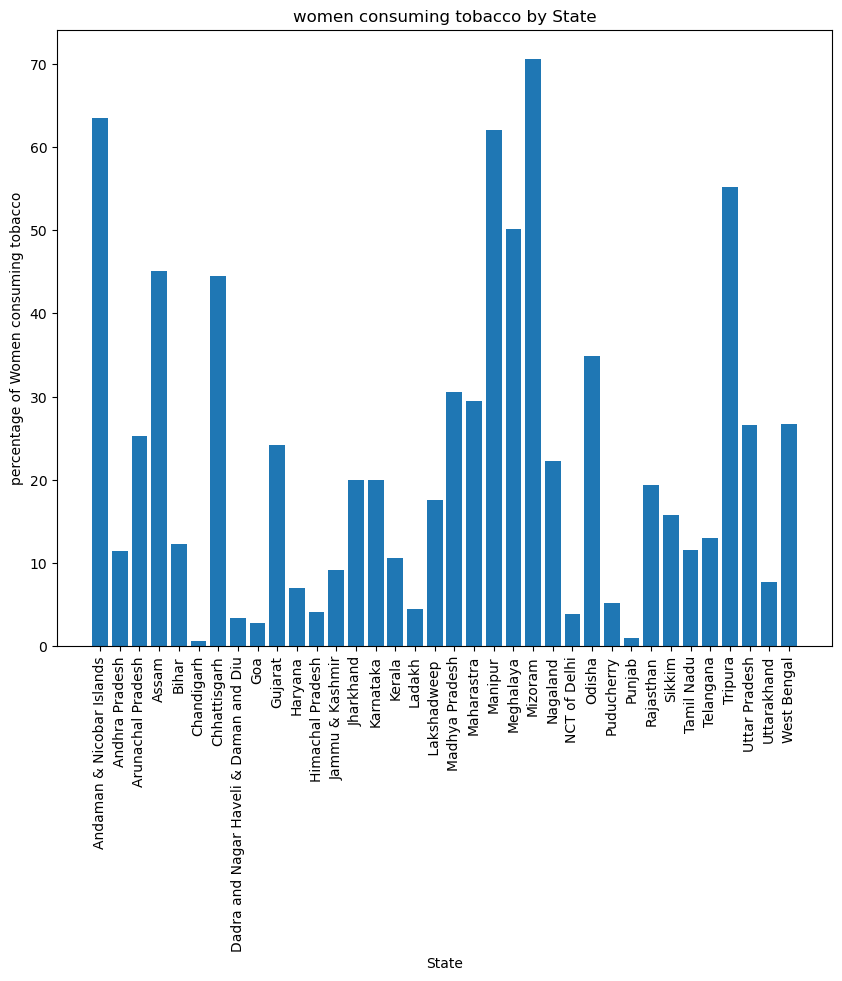

In [27]:
plt.figure(figsize=(10,8))
plt.bar(factsheet["State/UT"],factsheet["Women age 15 years and above who use any kind of tobacco (%)"])
plt.xlabel("State")
plt.ylabel("percentage of Women consuming tobacco")
plt.title("women consuming tobacco by State")
plt.xticks(rotation = 90)
plt.plot

<function matplotlib.pyplot.plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'>

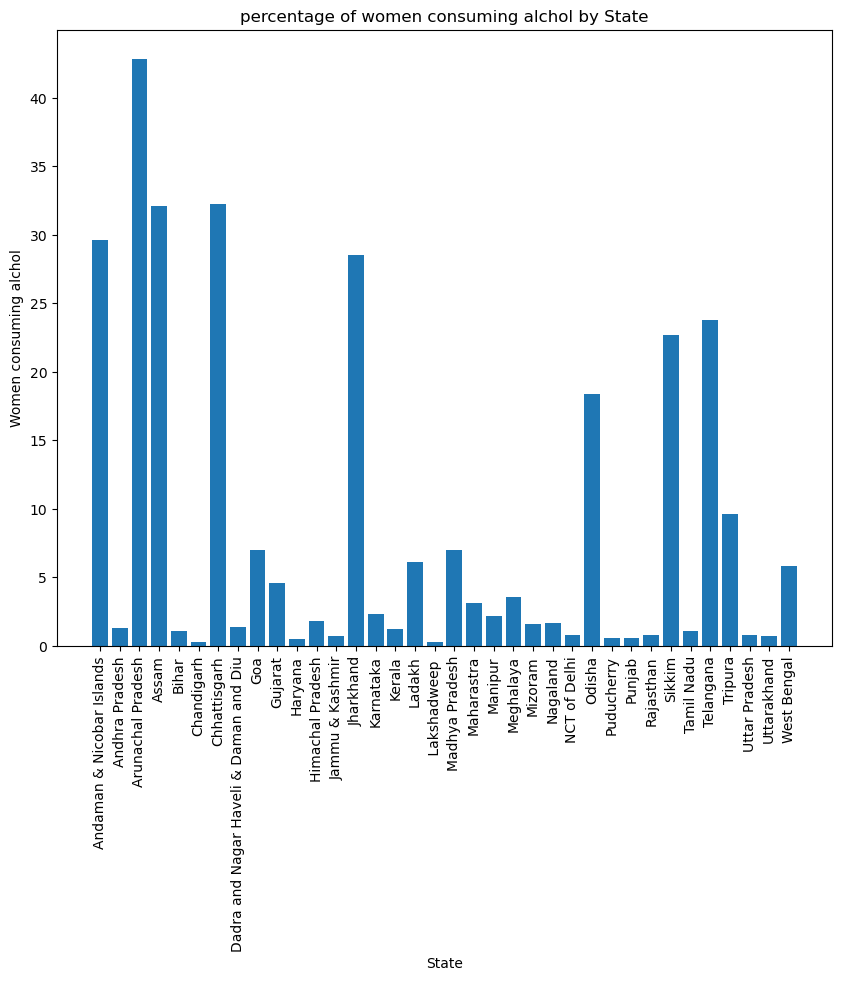

In [28]:
plt.figure(figsize=(10,8))
plt.bar(factsheet["State/UT"],factsheet["Women age 15 years and above who consume alcohol (%)"])
plt.xlabel("State")
plt.ylabel("Women consuming alchol")
plt.title("percentage of women consuming alchol by State")
plt.xticks(rotation = 90)
plt.plot

<function matplotlib.pyplot.plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'>

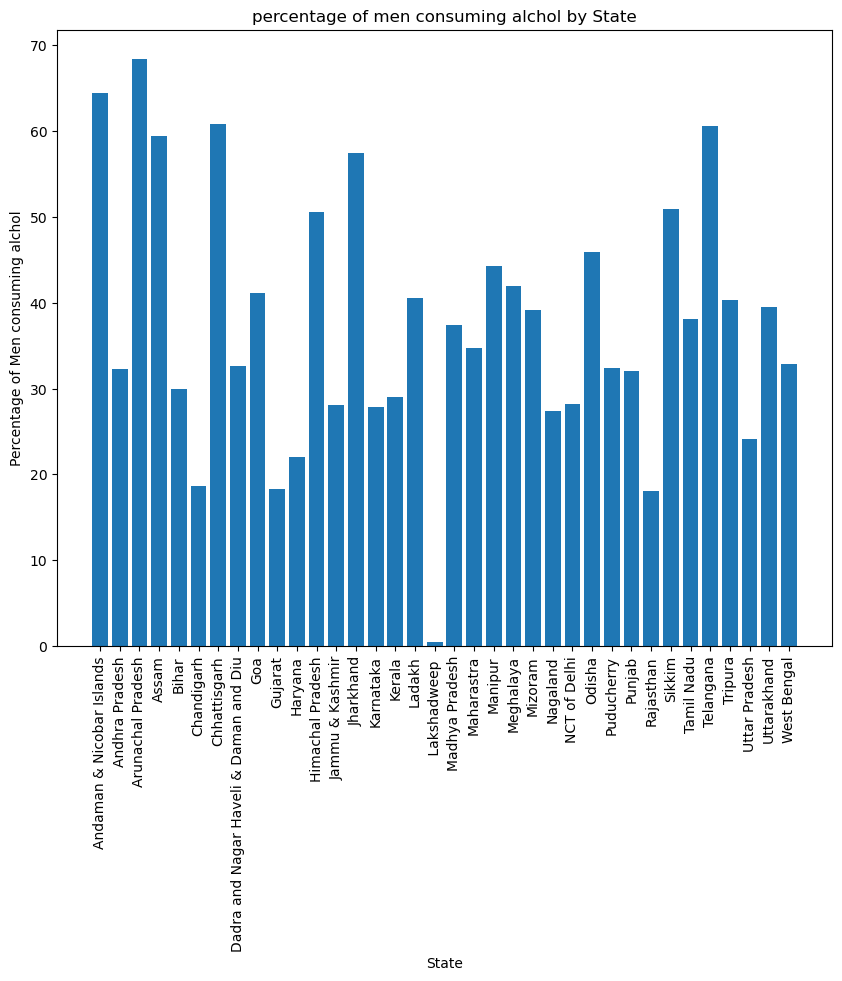

In [29]:
plt.figure(figsize=(10,8))
plt.bar(factsheet["State/UT"],factsheet["Men age 15 years and above who consume alcohol (%)"])
plt.xlabel("State")
plt.ylabel("Percentage of Men consuming alchol")
plt.title("percentage of men consuming alchol by State")
plt.xticks(rotation = 90)
plt.plot

<function matplotlib.pyplot.plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'>

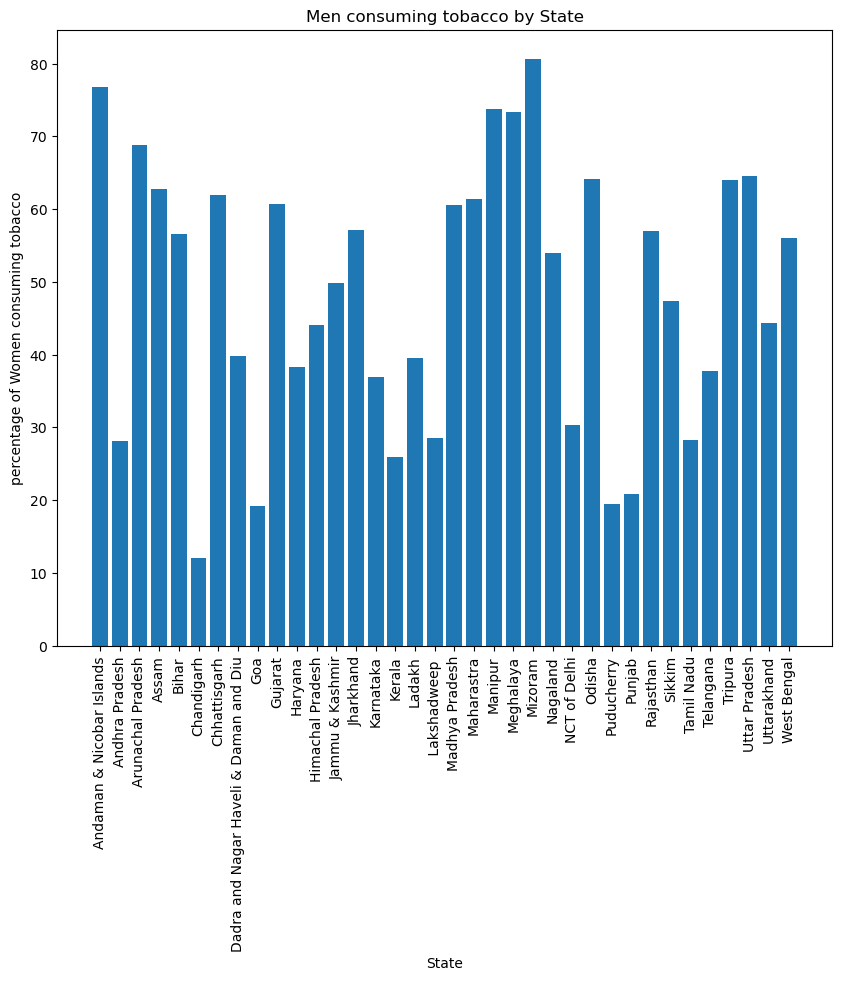

In [30]:
plt.figure(figsize=(10,8))
plt.bar(factsheet["State/UT"],factsheet["Men age 15 years and above who use any kind of tobacco (%)"])
plt.xlabel("State")
plt.ylabel("percentage of Women consuming tobacco")
plt.title("Men consuming tobacco by State")
plt.xticks(rotation = 90)
plt.plot

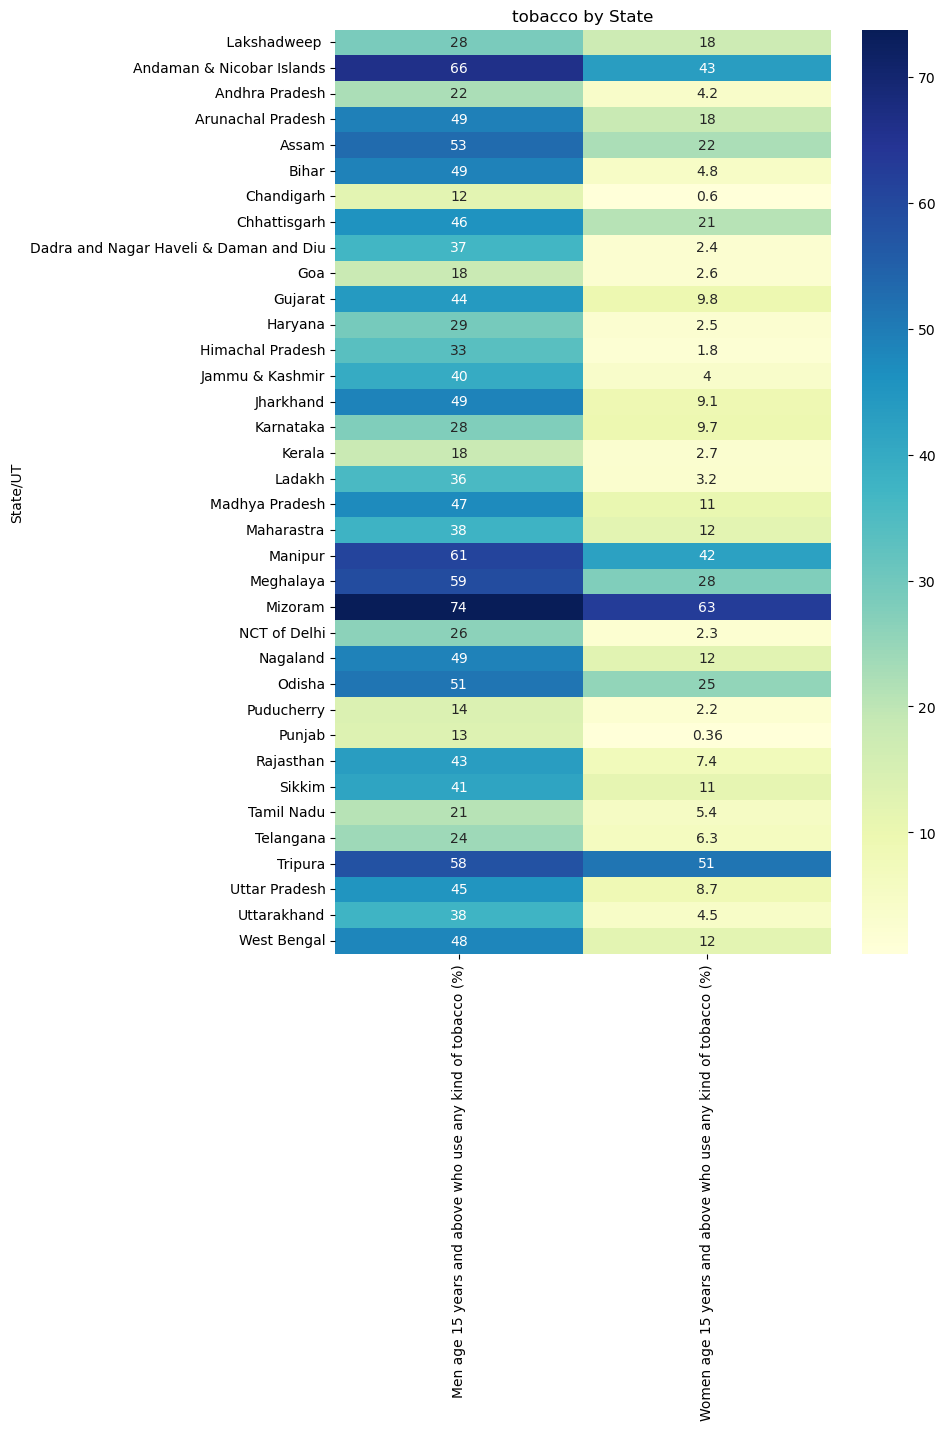

In [31]:
heat_data = factsheet.groupby("State/UT")[["Men age 15 years and above who use any kind of tobacco (%)",
                                   "Women age 15 years and above who use any kind of tobacco (%)"]].mean()

plt.figure(figsize=(8,12))

sns.heatmap(
    heat_data,
    annot=True,
    cmap="YlGnBu"
)

plt.title("tobacco by State")
plt.show()

In [32]:
factsheet[["State/UT","Men age 15 years and above who use any kind of tobacco (%)","Women age 15 years and above who use any kind of tobacco (%)"]]

,State/UT,Men age 15 years and above who use any kind of tobacco (%),Women age 15 years and above who use any kind of tobacco (%)
0,Andaman & Nicobar Islands,76.8,63.5
1,Andaman & Nicobar Islands,70.5,46.8
2,Andaman & Nicobar Islands,50.8,19.6
3,Andhra Pradesh,21.3,7.1
4,Andhra Pradesh,21.5,11.4
...,...,...,...
702,West Bengal,49.8,6.3
703,West Bengal,50.5,18.8
704,West Bengal,40.1,12.9
705,West Bengal,40.2,11.8


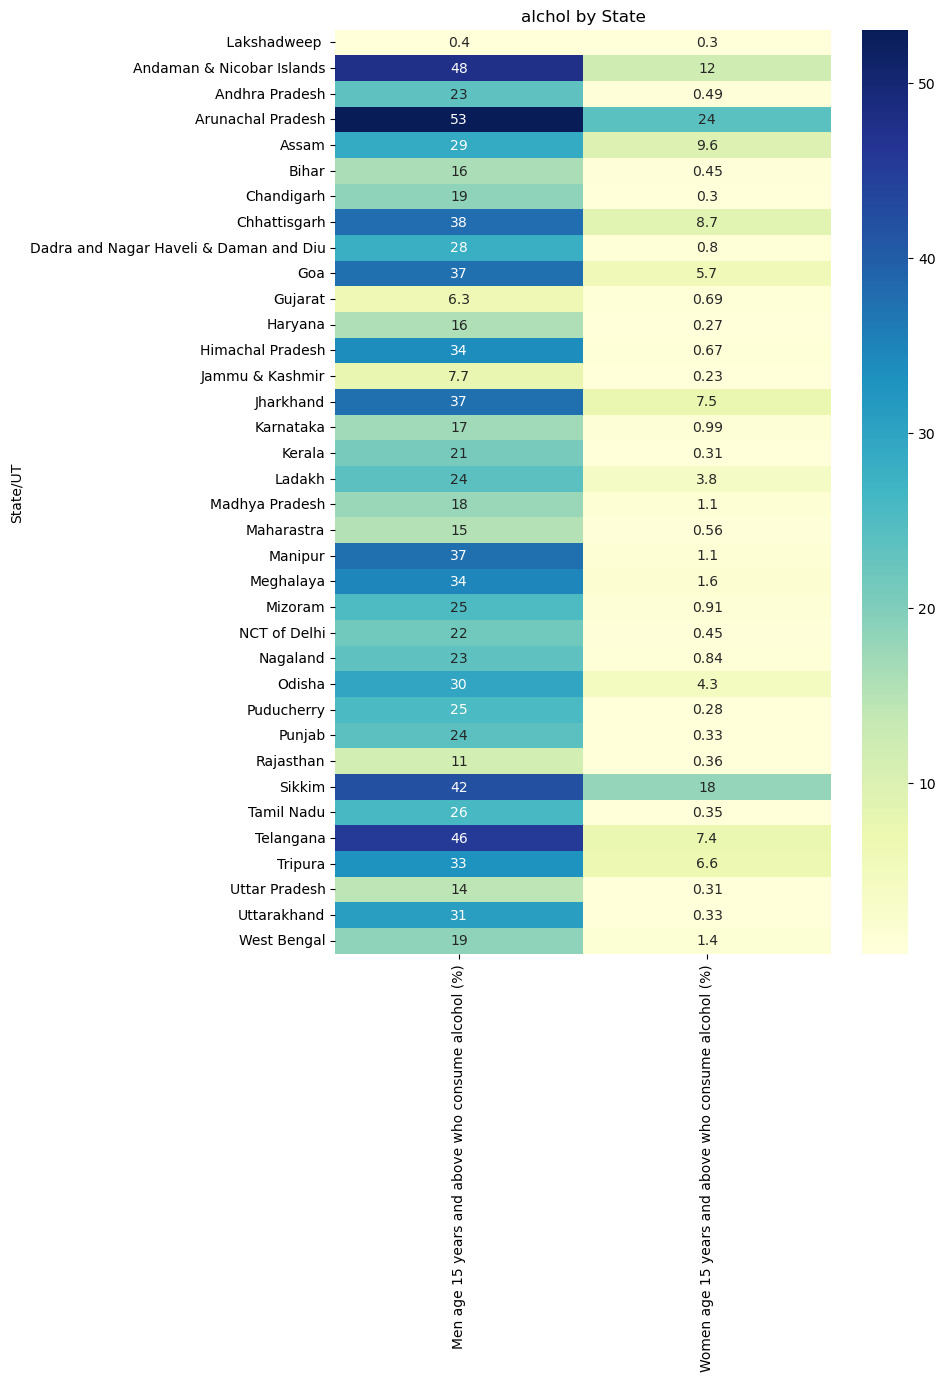

In [33]:
heat_data_1 = factsheet.groupby("State/UT")[["Men age 15 years and above who consume alcohol (%)",
                                   "Women age 15 years and above who consume alcohol (%)"]].mean()

plt.figure(figsize=(8,12))

sns.heatmap(
    heat_data_1,
    annot=True,
    cmap="YlGnBu"
)

plt.title("alchol by State")
plt.show()

In [ ]:
Women (age 15-49) who are literate4 (%)
Women (age 15-49)  with 10 or more years of schooling (%)
Women age 20-24 years married before age 18 years (%)
Women age 15-19 years who were already mothers or pregnant at the time of the survey (%)
Men age 15 years and above who consume alcohol (%)
Women age 15 years and above who consume alcohol (%)
Men age 15 years and above who use any kind of tobacco (%)
Women age 15 years and above who use any kind of tobacco (%)

In [34]:
df=factsheet[["District Names",
"State/UT",
"Number of Households surveyed",
"Number of Women age 15-49 years interviewed",
"Number of Men age 15-54 years interviewed","Women (age 15-49) who are literate4 (%)",
               "Women (age 15-49)  with 10 or more years of schooling (%)",
               "Women age 20-24 years married before age 18 years (%)",
              "Women age 15-19 years who were already mothers or pregnant at the time of the survey (%)",
               "Men age 15 years and above who consume alcohol (%)",
               "Women age 15 years and above who consume alcohol (%)",
               "Men age 15 years and above who use any kind of tobacco (%)",
               "Women age 15 years and above who use any kind of tobacco (%)"
               ]]
df

,District Names,State/UT,Number of Households surveyed,Number of Women age 15-49 years interviewed,Number of Men age 15-54 years interviewed,Women (age 15-49) who are literate4 (%),Women (age 15-49) with 10 or more years of schooling (%),Women age 20-24 years married before age 18 years (%),Women age 15-19 years who were already mothers or pregnant at the time of the survey (%),Men age 15 years and above who consume alcohol (%),Women age 15 years and above who consume alcohol (%),Men age 15 years and above who use any kind of tobacco (%),Women age 15 years and above who use any kind of tobacco (%)
0,Nicobars,Andaman & Nicobar Islands,882,764,125,87.5,53.5,11.4,1.8,64.5,29.6,76.8,63.5
1,North & Middle Andaman,Andaman & Nicobar Islands,874,789,108,84.0,41.0,15.4,3.8,45.3,5.1,70.5,46.8
2,South Andaman,Andaman & Nicobar Islands,868,844,134,86.7,57.5,17.1,2.8,32.8,1.7,50.8,19.6
3,Srikakulam,Andhra Pradesh,874,780,100,64.3,42.5,25.4,5.5,28.3,0.6,21.3,7.1
4,Vizianagaram,Andhra Pradesh,902,853,134,58.3,37.6,33.7,12.7,32.3,0.8,21.5,11.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
702,South Twenty Four Pargana,West Bengal,917,1089,148,85.6,34.9,41.9,13.1,16.5,0.4,49.8,6.3
703,Paschim Medinipur,West Bengal,910,1002,137,70.9,26.2,55.7,25.0,20.8,1.5,50.5,18.8
704,Purba Medinipur,West Bengal,873,957,131,77.0,30.9,57.6,22.0,14.8,2.0,40.1,12.9
705,Paschim Barddhaman,West Bengal,912,1190,184,73.5,37.1,31.8,15.4,14.6,0.8,40.2,11.8


In [35]:
df["District Names"].unique()

array(['Nicobars', 'North & Middle Andaman ', 'South Andaman ',
       'Srikakulam ', 'Vizianagaram ', 'Visakhapatnam ', 'East Godavari ',
       'West Godavari ', 'Krishna ', 'Guntur ', 'Prakasam ',
       'Sri Potti Sriramulu Nello ', 'Y.S.R. ', 'Kurnool ', 'Anantapur ',
       'Chittoor ', 'Tawang ', 'West Kameng ', 'East Kameng ',
       'Papum Pare ', 'Upper Subansiri ', 'Upper Siang ', 'Changlang ',
       'Lower Subansiri ', 'Dibang Valley ', 'Lower Dibang Valley ',
       'Anjaw ', 'East Siang ', 'Kra Daadi ', 'Kurung Kumey ', 'Lohit ',
       'Longding ', 'Namsai ', 'Siang ', 'Tirap ', 'West Siang ',
       'Kokrajhar ', 'Goalpara ', 'Barpeta ', 'Morigaon ', 'Lakhimpur ',
       'Dhemaji ', 'Tinsukia ', 'Dibrugarh ', 'Golaghat ', 'Dima Hasao ',
       'Cachar ', 'Karimganj ', 'Hailakandi ', 'Bongaigaon ', 'Chirang ',
       'Kamrup ', 'Kamrup Metropolitan ', 'Nalbari ', 'Baksa ',
       'Darrang ', 'Udalguri ', 'Biswanath ', 'Charaideo ', 'Dhubri ',
       'Hojai ', 'Jorhat ',

In [36]:
df["District Names"].nunique()

699

In [37]:
df.shape

(707, 13)

In [38]:
factsheet.shape

(707, 109)

In [39]:
df[df["District Names"]=="Cuddalore"]

,District Names,State/UT,Number of Households surveyed,Number of Women age 15-49 years interviewed,Number of Men age 15-54 years interviewed,Women (age 15-49) who are literate4 (%),Women (age 15-49) with 10 or more years of schooling (%),Women age 20-24 years married before age 18 years (%),Women age 15-19 years who were already mothers or pregnant at the time of the survey (%),Men age 15 years and above who consume alcohol (%),Women age 15 years and above who consume alcohol (%),Men age 15 years and above who use any kind of tobacco (%),Women age 15 years and above who use any kind of tobacco (%)


In [40]:
df[df["State/UT"]=="Tamil Nadu"]

,District Names,State/UT,Number of Households surveyed,Number of Women age 15-49 years interviewed,Number of Men age 15-54 years interviewed,Women (age 15-49) who are literate4 (%),Women (age 15-49) with 10 or more years of schooling (%),Women age 20-24 years married before age 18 years (%),Women age 15-19 years who were already mothers or pregnant at the time of the survey (%),Men age 15 years and above who consume alcohol (%),Women age 15 years and above who consume alcohol (%),Men age 15 years and above who use any kind of tobacco (%),Women age 15 years and above who use any kind of tobacco (%)
528,Thiruvallur,Tamil Nadu,806,775,124,85.9,57.2,13.4,5.8,26.7,0.1,18.3,1.7
529,Chennai,Tamil Nadu,743,660,101,96.1,76.7,1.9,3.0,16.1,0.1,8.9,0.7
530,Kancheepuram,Tamil Nadu,816,796,102,84.5,56.8,10.0,2.5,28.9,0.8,17.5,4.5
531,Vellore,Tamil Nadu,880,886,108,84.7,52.5,14.9,4.9,23.0,0.3,14.4,4.3
532,Tiruvannamalai,Tamil Nadu,874,786,108,81.7,50.2,11.6,8.5,24.2,0.2,17.2,4.8
533,Viluppuram,Tamil Nadu,859,812,109,77.8,45.7,19.0,7.9,38.1,0.2,25.1,8.8
534,Salem,Tamil Nadu,882,754,99,83.2,51.3,23.7,8.9,24.1,0.2,23.5,6.5
535,Namakkal,Tamil Nadu,888,700,109,88.9,55.7,14.2,6.5,27.1,0.1,19.8,6.6
536,Erode,Tamil Nadu,877,774,110,83.1,57.8,13.7,14.8,23.5,0.1,26.2,11.1
537,The Nilgiris,Tamil Nadu,904,850,120,90.6,63.4,11.1,4.5,25.9,1.1,21.5,6.8


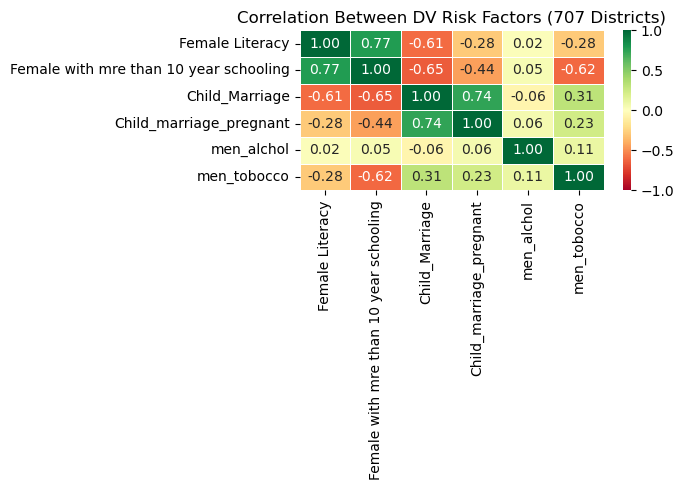

,Female Literacy,Female with mre than 10 year schooling,Child_Marriage,Child_marriage_pregnant,men_alchol,men_tobocco
Female Literacy,1.000000,0.774181,-0.606492,-0.281443,0.017389,-0.281603
Female with mre than 10 year schooling,0.774181,1.000000,-0.652333,-0.439164,0.045948,-0.615556
Child_Marriage,-0.606492,-0.652333,1.000000,0.738134,-0.063104,0.308250
Child_marriage_pregnant,-0.281443,-0.439164,0.738134,1.000000,0.058248,0.226566
men_alchol,0.017389,0.045948,-0.063104,0.058248,1.000000,0.109180
men_tobocco,-0.281603,-0.615556,0.308250,0.226566,0.109180,1.000000


In [41]:
cols=["Women (age 15-49) who are literate4 (%)",
      "Women (age 15-49)  with 10 or more years of schooling (%)",
      "Women age 20-24 years married before age 18 years (%)",
      "Women age 15-19 years who were already mothers or pregnant at the time of the survey (%)",
      "Men age 15 years and above who consume alcohol (%)",
      "Men age 15 years and above who use any kind of tobacco (%)"
     ]
for col in cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(r'[()]', '', regex=True)
    )

    df[col] = pd.to_numeric(df[col], errors='coerce')
corr=df[cols].corr()
corr.columns = ['Female Literacy', 'Female with mre than 10 year schooling', 'Child_Marriage', 'Child_marriage_pregnant',"men_alchol","men_tobocco"]
corr.index   = ['Female Literacy', 'Female with mre than 10 year schooling', 'Child_Marriage', 'Child_marriage_pregnant',"men_alchol","men_tobocco"]
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Between DV Risk Factors (707 Districts)', fontsize=12)
plt.tight_layout()
plt.show()
corr

In [42]:
dv.shape
dv.head(59)

,Category,Background Characteristic,Percentage Ever Experienced Physical Violence,Distribution %,Number
0,Age Group,18-19,16.4,3.9,3542
1,Age Group,20-24,22.8,13.4,11017
2,Age Group,25-29,28.1,16.4,13855
3,Age Group,30-39,31.9,36.4,25859
4,Age Group,40-49,32.1,29.9,17908
5,Education Level,No education,39.3,34.6,19213
6,Education Level,Incomplete Primary,34.0,14.8,9642
7,Education Level,Incomplete Secondary,26.5,41.2,31828
8,Education Level,Completed Secondary,20.1,1.7,1464
9,Education Level,Higher & above,14.7,7.9,10167


In [43]:
dv.columns = ['Category', 'Group', 'DV_Percentage', 'Distribution', 'Sample_Size']

dv = dv[~dv['Group'].str.contains("Don't know|Missing|Total", na=False)]

dv = dv.sort_values(['Category', 'DV_Percentage'], ascending=[True, False])

dv = dv.reset_index(drop=True)

for category in dv['Category'].unique():
    subset = dv[dv['Category'] == category][['Group', 'DV_Percentage']]
    print(f"\n=== {category} ===")
    print(subset.to_string(index=False))


=== Age Group ===
Group  DV_Percentage
40-49           32.1
30-39           31.9
25-29           28.1
20-24           22.8
18-19           16.4

=== Caste ===
                 Group  DV_Percentage
       Schedule Castes           33.8
       Schedule Tribes           30.9
Other Backward Classes           30.0
          None of them           22.0

=== Education Level ===
               Group  DV_Percentage
        No education           39.3
  Incomplete Primary           34.0
Incomplete Secondary           26.5
 Completed Secondary           20.1
      Higher & above           14.7

=== Geographical Region ===
     Group  DV_Percentage
     South           34.2
      East           32.2
   Central           30.0
North-east           29.8
      West           20.8
     North           17.7

=== Husband Education Level ===
          Group  DV_Percentage
   No education           41.3
  Primary level           37.0
Secondary level           28.8
 Higher & above           19.6

=== Husba

In [44]:
dv

,Category,Group,DV_Percentage,Distribution,Sample_Size
0,Age Group,40-49,32.1,29.9,17908
1,Age Group,30-39,31.9,36.4,25859
2,Age Group,25-29,28.1,16.4,13855
3,Age Group,20-24,22.8,13.4,11017
4,Age Group,18-19,16.4,3.9,3542
5,Caste,Schedule Castes,33.8,24.5,13623
6,Caste,Schedule Tribes,30.9,9.6,14155
7,Caste,Other Backward Classes,30.0,43.6,27559
8,Caste,None of them,22.0,16.1,13071
9,Education Level,No education,39.3,34.6,19213


In [45]:

categories = dv['Category'].unique()

wide = pd.DataFrame()

for category in categories:
    subset = dv[dv['Category'] == category][['Group', 'DV_Percentage', 'Distribution', 'Sample_Size']].reset_index(drop=True)
    
    col = category.replace(' ', '_').replace("'", "")
    
    wide[col]                    = subset['Group']
    wide[col + '_DV_Pct']        = subset['DV_Percentage']
    wide[col + '_Distribution']  = subset['Distribution']
    wide[col + '_Sample_Size']   = subset['Sample_Size']

print(wide.to_string())
print("\nShape:", wide.shape)


  Age_Group  Age_Group_DV_Pct  Age_Group_Distribution  Age_Group_Sample_Size                   Caste  Caste_DV_Pct  Caste_Distribution  Caste_Sample_Size       Education_Level  Education_Level_DV_Pct  Education_Level_Distribution  Education_Level_Sample_Size Geographical_Region  Geographical_Region_DV_Pct  Geographical_Region_Distribution  Geographical_Region_Sample_Size Husband_Education_Level  Husband_Education_Level_DV_Pct  Husband_Education_Level_Distribution  Husband_Education_Level_Sample_Size Husband_and_Wife_Age_Gap  Husband_and_Wife_Age_Gap_DV_Pct  Husband_and_Wife_Age_Gap_Distribution  Husband_and_Wife_Age_Gap_Sample_Size Husband_and_Wife_Education_Gap  Husband_and_Wife_Education_Gap_DV_Pct  Husband_and_Wife_Education_Gap_Distribution  Husband_and_Wife_Education_Gap_Sample_Size Husbands_Drinking_Habits  Husbands_Drinking_Habits_DV_Pct  Husbands_Drinking_Habits_Distribution  Husbands_Drinking_Habits_Sample_Size                     Marital_Status  Marital_Status_DV_Pct  Marital

In [46]:
wide

,Age_Group,Age_Group_DV_Pct,Age_Group_Distribution,Age_Group_Sample_Size,Caste,Caste_DV_Pct,Caste_Distribution,Caste_Sample_Size,Education_Level,Education_Level_DV_Pct,...,Religion_Distribution,Religion_Sample_Size,Wealth_Index,Wealth_Index_DV_Pct,Wealth_Index_Distribution,Wealth_Index_Sample_Size,Working_Status,Working_Status_DV_Pct,Working_Status_Distribution,Working_Status_Sample_Size
0,40-49,32.1,29.9,17908,Schedule Castes,33.8,24.5,13623.0,No education,39.3,...,81.0,54221.0,Lowest,37.6,24.2,15570,Employed for cash,35.7,36.4,20776.0
1,30-39,31.9,36.4,25859,Schedule Tribes,30.9,9.6,14155.0,Incomplete Primary,34.0,...,14.8,8821.0,Second,35.0,25.3,16223,Employed not for cash,33.1,5.9,4932.0
2,25-29,28.1,16.4,13855,Other Backward Classes,30.0,43.6,27559.0,Incomplete Secondary,26.5,...,2.2,5570.0,Middle,29.6,22.0,15082,Not employed,25.2,57.6,46606.0
3,20-24,22.8,13.4,11017,None of them,22.0,16.1,13071.0,Completed Secondary,20.1,...,1.9,3702.0,Fourth,24.1,17.8,13639,NaN,NaN,NaN,NaN
4,18-19,16.4,3.9,3542,NaN,NaN,NaN,NaN,Higher & above,14.7,...,NaN,NaN,Highest,16.9,10.8,11800,NaN,NaN,NaN,NaN


In [47]:
dv

,Category,Group,DV_Percentage,Distribution,Sample_Size
0,Age Group,40-49,32.1,29.9,17908
1,Age Group,30-39,31.9,36.4,25859
2,Age Group,25-29,28.1,16.4,13855
3,Age Group,20-24,22.8,13.4,11017
4,Age Group,18-19,16.4,3.9,3542
5,Caste,Schedule Castes,33.8,24.5,13623
6,Caste,Schedule Tribes,30.9,9.6,14155
7,Caste,Other Backward Classes,30.0,43.6,27559
8,Caste,None of them,22.0,16.1,13071
9,Education Level,No education,39.3,34.6,19213


In [48]:
print(dv[['Category', 'Group', 'DV_Percentage']])

                          Category                              Group  \
0                        Age Group                              40-49   
1                        Age Group                              30-39   
2                        Age Group                              25-29   
3                        Age Group                              20-24   
4                        Age Group                              18-19   
5                            Caste                    Schedule Castes   
6                            Caste                    Schedule Tribes   
7                            Caste             Other Backward Classes   
8                            Caste                       None of them   
9                  Education Level                       No education   
10                 Education Level                 Incomplete Primary   
11                 Education Level               Incomplete Secondary   
12                 Education Level                C

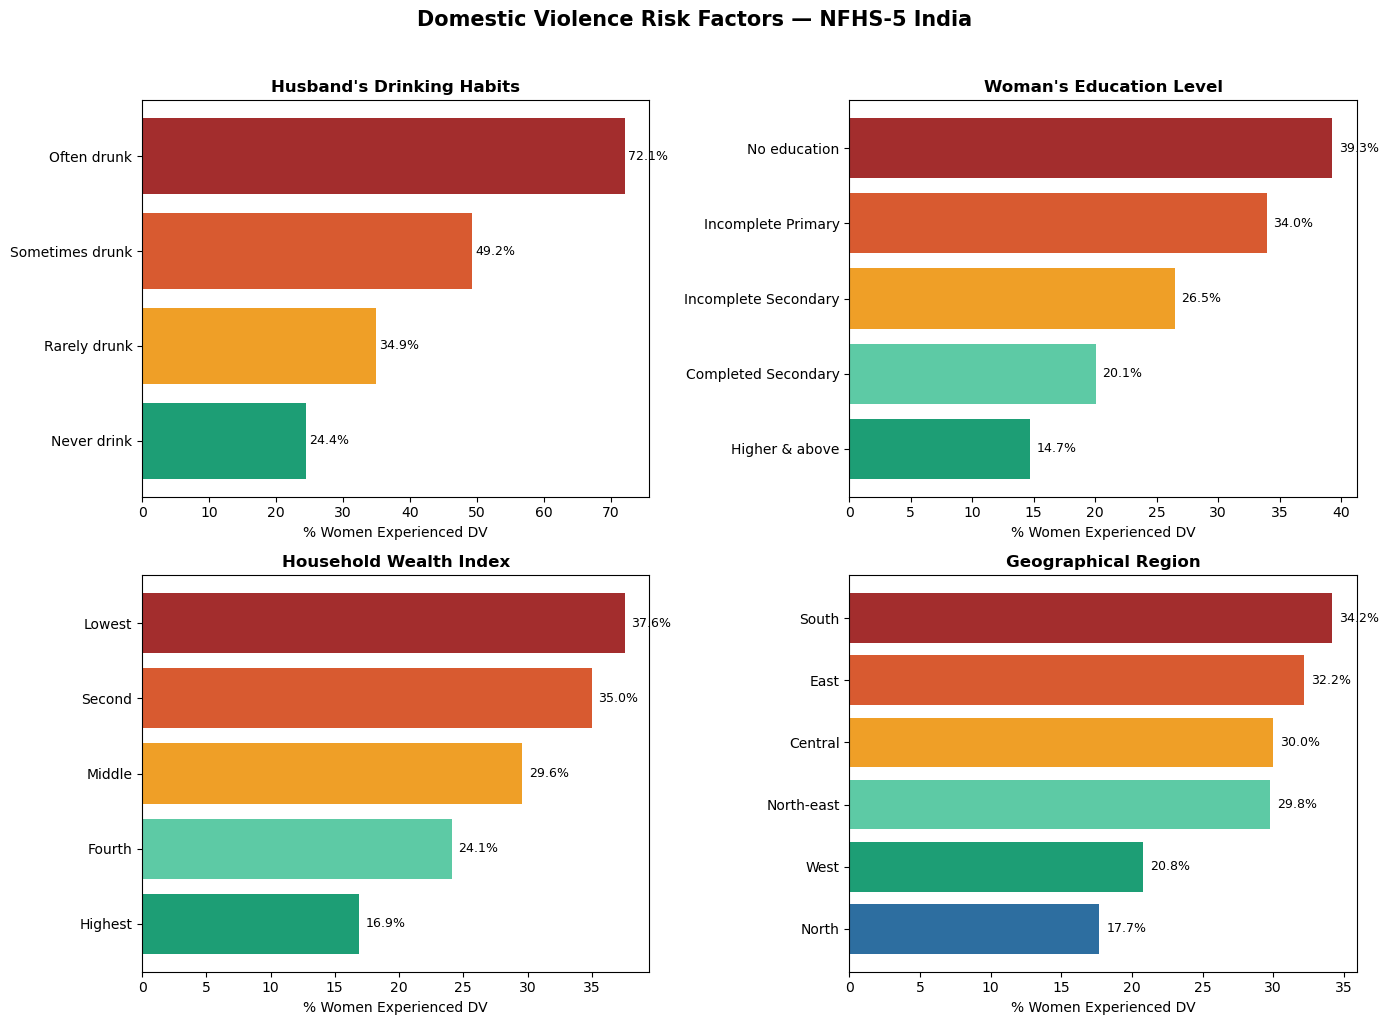

In [49]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Domestic Violence Risk Factors — NFHS-5 India', fontsize=15, fontweight='bold', y=1.02)

colors = ['#A32D2D', '#D85A30', '#EF9F27', '#5DCAA5', '#1D9E75']

# ---- Chart 1: Drinking Habits ----
drink = dv[dv['Category'] == "Husband's Drinking Habits"][['Group', 'DV_Percentage']]
axes[0,0].barh(drink['Group'], drink['DV_Percentage'], color=['#A32D2D','#D85A30','#EF9F27','#1D9E75'])
axes[0,0].set_title("Husband's Drinking Habits", fontweight='bold')
axes[0,0].set_xlabel('% Women Experienced DV')
axes[0,0].invert_yaxis()
for i, v in enumerate(drink['DV_Percentage']):
    axes[0,0].text(v + 0.5, i, f'{v}%', va='center', fontsize=9)

# ---- Chart 2: Education Level ----
edu = dv[dv['Category'] == 'Education Level'][['Group', 'DV_Percentage']]
axes[0,1].barh(edu['Group'], edu['DV_Percentage'], color=['#A32D2D','#D85A30','#EF9F27','#5DCAA5','#1D9E75'])
axes[0,1].set_title("Woman's Education Level", fontweight='bold')
axes[0,1].set_xlabel('% Women Experienced DV')
axes[0,1].invert_yaxis()
for i, v in enumerate(edu['DV_Percentage']):
    axes[0,1].text(v + 0.5, i, f'{v}%', va='center', fontsize=9)

# ---- Chart 3: Wealth Index ----
wealth = dv[dv['Category'] == 'Wealth Index'][['Group', 'DV_Percentage']]
axes[1,0].barh(wealth['Group'], wealth['DV_Percentage'], color=['#A32D2D','#D85A30','#EF9F27','#5DCAA5','#1D9E75'])
axes[1,0].set_title("Household Wealth Index", fontweight='bold')
axes[1,0].set_xlabel('% Women Experienced DV')
axes[1,0].invert_yaxis()
for i, v in enumerate(wealth['DV_Percentage']):
    axes[1,0].text(v + 0.5, i, f'{v}%', va='center', fontsize=9)

# ---- Chart 4: Geographical Region ----
region = dv[dv['Category'] == 'Geographical Region'][['Group', 'DV_Percentage']]
axes[1,1].barh(region['Group'], region['DV_Percentage'], color=['#A32D2D','#D85A30','#EF9F27','#5DCAA5','#1D9E75','#2D6EA0'])
axes[1,1].set_title("Geographical Region", fontweight='bold')
axes[1,1].set_xlabel('% Women Experienced DV')
axes[1,1].invert_yaxis()
for i, v in enumerate(region['DV_Percentage']):
    axes[1,1].text(v + 0.5, i, f'{v}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()


In [50]:
crime.shape
crime.columns

Index(['State/UT', 'Trafficking', 'Murder with Rape/Gang Rape', 'Dowry Deaths',
       'Abetment to Suicide of Women ', 'Miscarriage', 'Acid Attack',
       'Attempt to Acid Attack', 'Cruelty by Husband/relatives',
       'Kidnapping/Abduction', 'Selling of Minor Girls ',
       'Buying of Minor Girls', 'Rape', 'Attempt to Commit Rape',
       'Assault to Outrage her Modesty', 'Insult to the Modesty of Women',
       'Assault due to Dowry', 'Domestic violence',
       'Cyber Crimes committed against women',
       'Sexual Violence towards girl child',
       'Indecent Representation of Women',
       'Total Crime against Women (IPC &SLL)'],
      dtype='object')

In [51]:
crime_needed = ['State/UT', 'Domestic violence', 'Cruelty by Husband/relatives', 
               'Dowry Deaths', 'Rape', 'Total Crime against Women (IPC &SLL)']

cr_needed=crime[crime_needed]

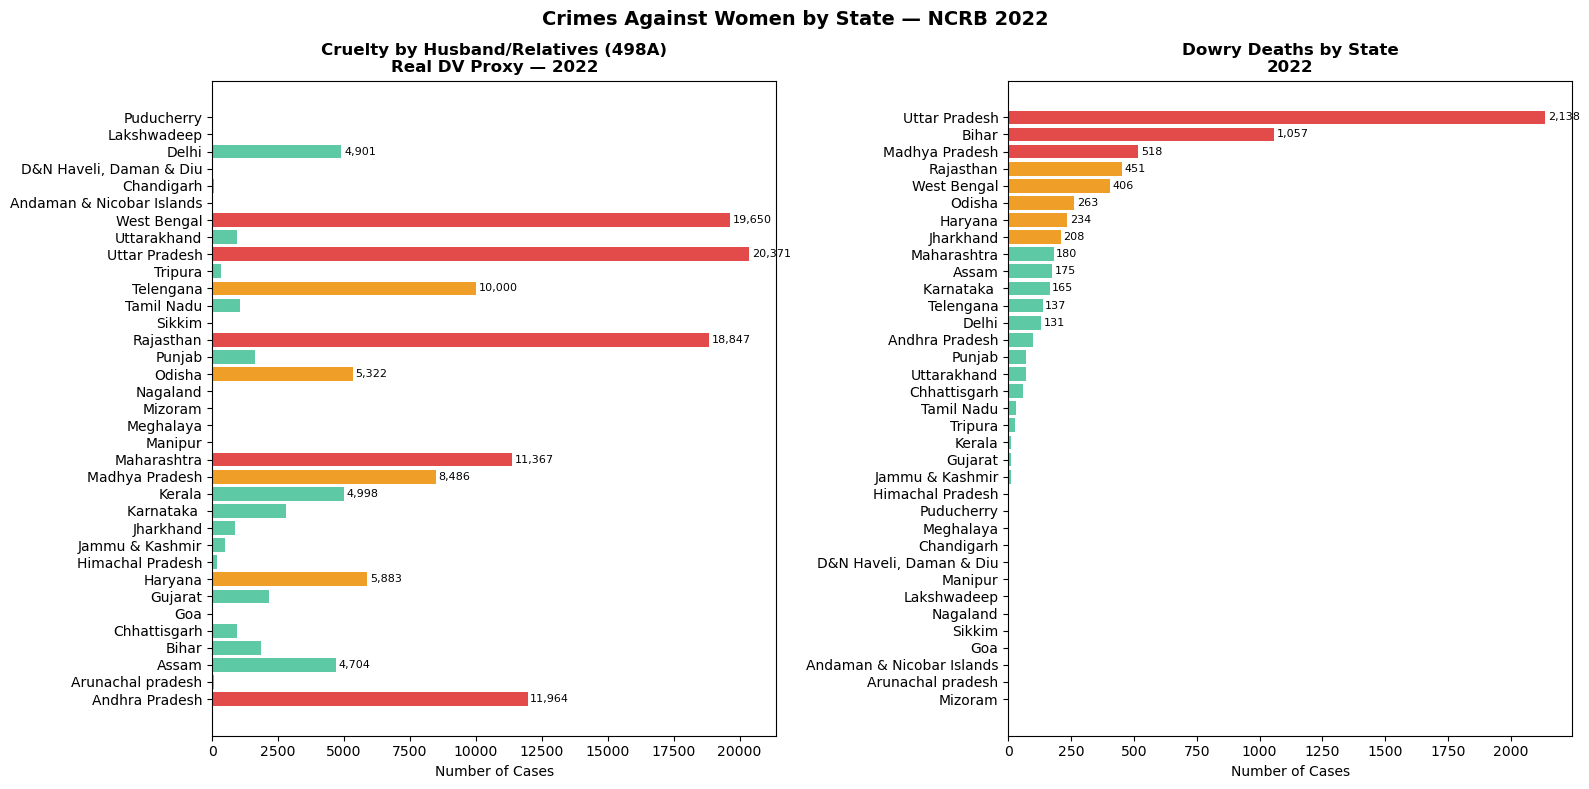

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Crimes Against Women by State — NCRB 2022', fontsize=14, fontweight='bold')

# ---- Chart 1: Cruelty by Husband (498A) ----
colors_1 = ['#E24B4A' if x > 10000 else '#EF9F27' if x > 5000 else '#5DCAA5' 
            for x in cr_needed['Cruelty by Husband/relatives']]

axes[0].barh(cr_needed['State/UT'], 
             cr_needed['Cruelty by Husband/relatives'],
             color=colors_1)
axes[0].set_title('Cruelty by Husband/Relatives (498A)\nReal DV Proxy — 2022', fontweight='bold')
axes[0].set_xlabel('Number of Cases')
for i, v in enumerate(cr_needed['Cruelty by Husband/relatives']):
    if v > 3000:
        axes[0].text(v + 100, i, f'{v:,}', va='center', fontsize=8)

# ---- Chart 2: Dowry Deaths ----
states_dowry = cr_needed.sort_values('Dowry Deaths', ascending=True)
colors_2 = ['#E24B4A' if x > 500 else '#EF9F27' if x > 200 else '#5DCAA5' 
            for x in states_dowry['Dowry Deaths']]

axes[1].barh(states_dowry['State/UT'],
             states_dowry['Dowry Deaths'],
             color=colors_2)
axes[1].set_title('Dowry Deaths by State\n2022', fontweight='bold')
axes[1].set_xlabel('Number of Cases')
for i, v in enumerate(states_dowry['Dowry Deaths']):
    if v > 100:
        axes[1].text(v + 10, i, f'{v:,}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

In [53]:
cr_needed


,State/UT,Domestic violence,Cruelty by Husband/relatives,Dowry Deaths,Rape,Total Crime against Women (IPC &SLL)
0,Andhra Pradesh,0,11964,100,621,25503
1,Arunachal pradesh,1,74,0,74,335
2,Assam,0,4704,175,1113,14148
3,Bihar,0,1850,1057,881,20222
4,Chhattisgarh,0,942,57,1246,8693
5,Goa,0,6,0,73,273
6,Gujarat,1,2166,10,610,7731
7,Haryana,1,5883,234,1790,16743
8,Himachal Pradesh,2,196,1,360,1551
9,Jammu & Kashmir,0,500,9,287,3716


In [54]:
cr_needed["Domestic violence"].value_counts()

Domestic violence
0      23
1       4
3       3
2       1
67      1
371     1
10      1
5       1
Name: count, dtype: int64

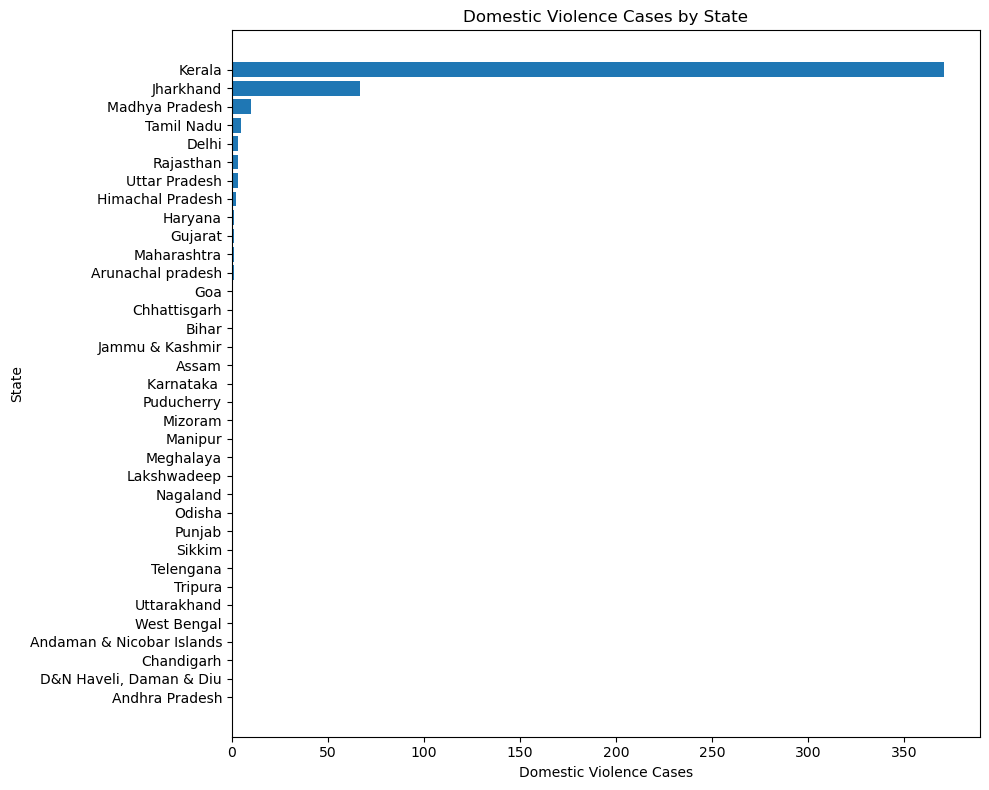

In [67]:
states_dv = cr_needed.sort_values(
    'Domestic violence'
)

plt.figure(figsize=(10,8))

plt.barh(
    states_dv['State/UT'],
    states_dv['Domestic violence']
)

plt.xlabel('Domestic Violence Cases')
plt.ylabel('State')
plt.title('Domestic Violence Cases by State')

plt.tight_layout()
plt.show()

<Axes: ylabel='State/UT'>

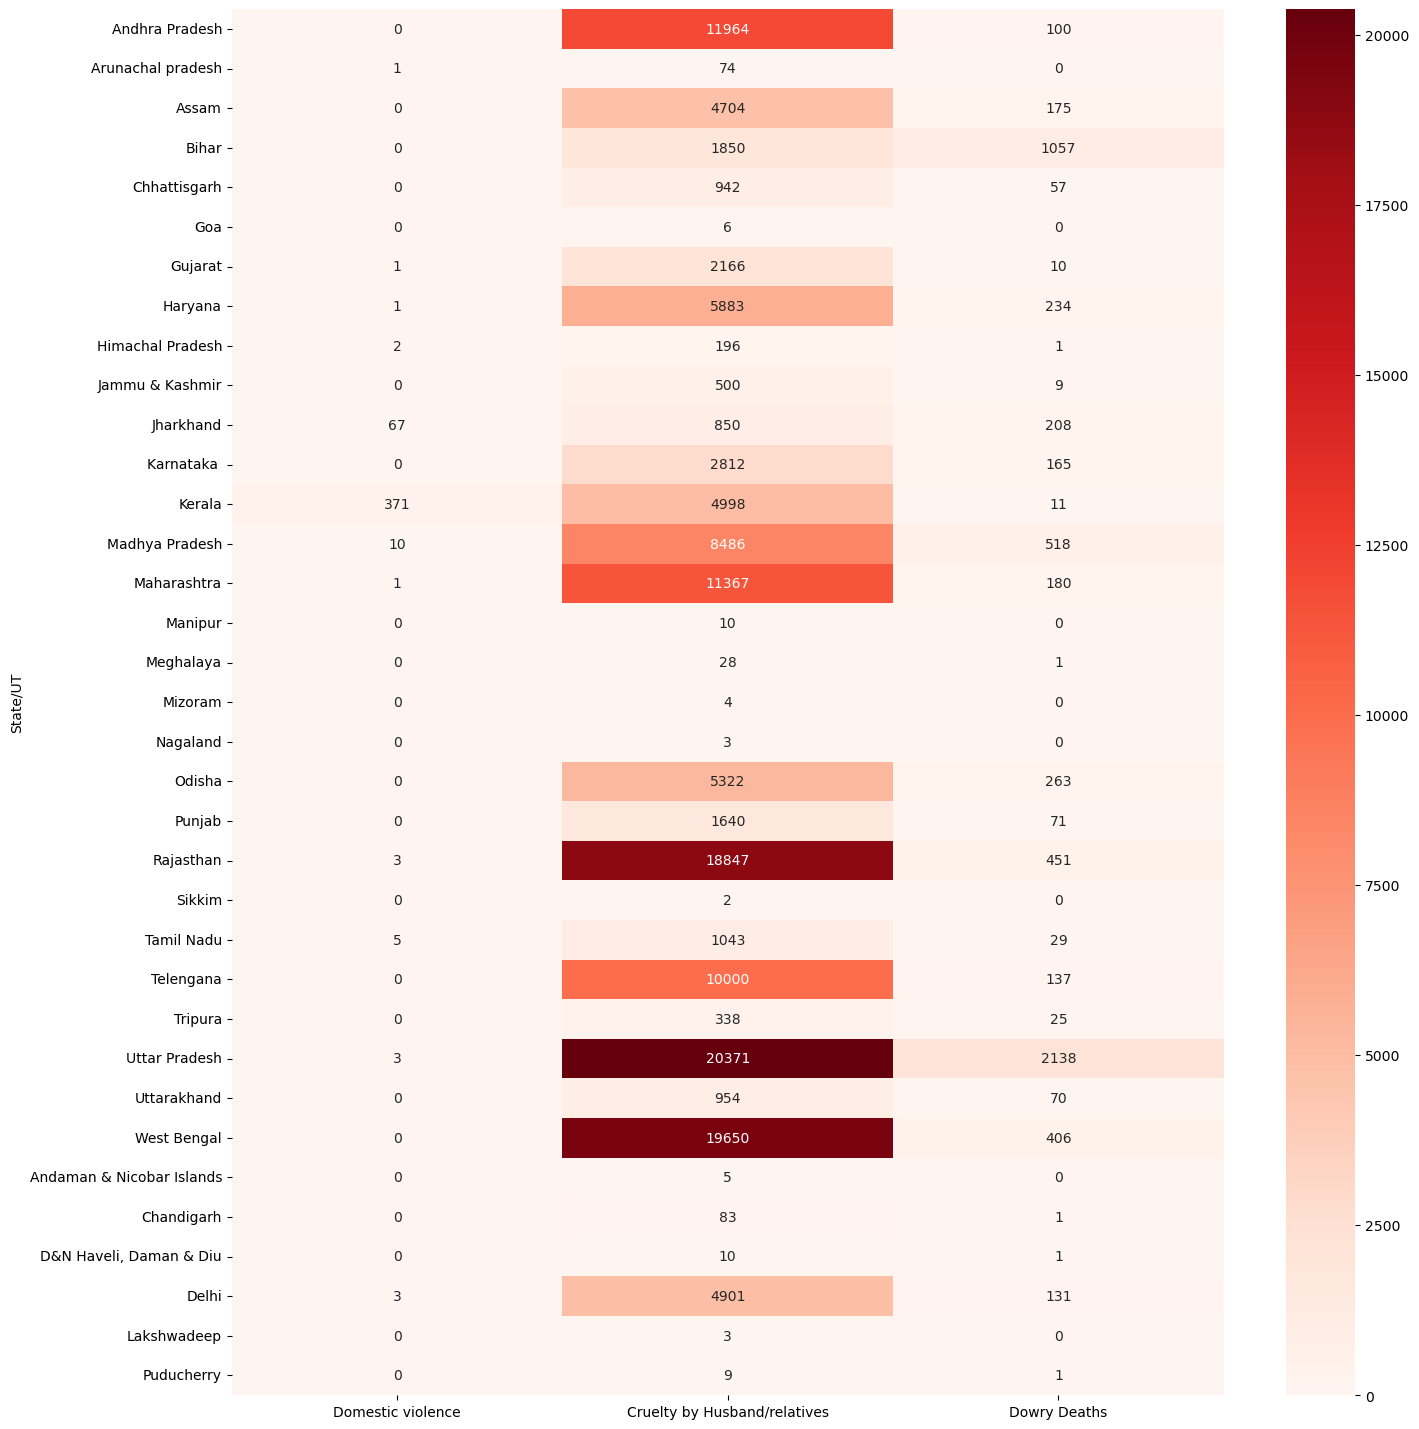

In [63]:
plt.figure(figsize=(16,18))
heat_data = cr_needed[
    ["State/UT","Domestic violence","Cruelty by Husband/relatives","Dowry Deaths"]
]

heat_data = heat_data.set_index("State/UT")

sns.heatmap(
    heat_data,
    cmap="Reds",
    annot=True,
    fmt=".0f"
)

In [68]:
print("NCRB states:")
print(cr_needed['State/UT'].tolist())

print("\nNFHS states:")
print(factsheet['State/UT'].unique().tolist())

NCRB states:
['Andhra Pradesh', 'Arunachal pradesh', 'Assam', 'Bihar', 'Chhattisgarh', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir', 'Jharkhand', 'Karnataka ', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telengana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal', 'Andaman & Nicobar Islands', 'Chandigarh', 'D&N Haveli, Daman & Diu', 'Delhi', 'Lakshwadeep', 'Puducherry']

NFHS states:
['Andaman & Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra and Nagar Haveli & Daman and Diu', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Ladakh', ' Lakshadweep ', 'Madhya Pradesh', 'Maharastra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'NCT of Delhi', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura'

In [70]:
state_name_fixes = {
    # NCRB fixes
    'Arunachal pradesh'      : 'Arunachal Pradesh',
    'Karnataka '             : 'Karnataka',
    'Telengana'              : 'Telangana',
    'Lakshwadeep'            : 'Lakshadweep',
    'D&N Haveli, Daman & Diu': 'Dadra and Nagar Haveli & Daman and Diu',
    'Delhi'                  : 'NCT of Delhi',

    # NFHS fixes
    'Maharastra'             : 'Maharashtra',
    ' Lakshadweep '          : 'Lakshadweep',
    'NCT of Delhi'           : 'Delhi',
}

# Apply fixes to NCRB
cr_needed['State/UT'] = cr_needed['State/UT'].str.strip()
cr_needed['State/UT'] = cr_needed['State/UT'].replace(state_name_fixes)

# Apply fixes to NFHS district file
factsheet['State/UT'] = factsheet['State/UT'].str.strip()
factsheet['State/UT'] = factsheet['State/UT'].replace(state_name_fixes)

print("Fixed! Checking remaining mismatches...")

# Check what still doesn't match
ncrb_states = set(cr_needed['State/UT'].unique())
nfhs_states = set(factsheet['State/UT'].unique())

only_in_ncrb = ncrb_states - nfhs_states
only_in_nfhs = nfhs_states - ncrb_states

print("\nStill only in NCRB:", only_in_ncrb)
print("Still only in NFHS:", only_in_nfhs)


Fixed! Checking remaining mismatches...

Still only in NCRB: {'Delhi'}
Still only in NFHS: {'NCT of Delhi', 'Ladakh'}


In [71]:
cr_needed['State/UT'] = cr_needed['State/UT'].replace({'Delhi': 'NCT of Delhi'})

# Verify
ncrb_states = set(cr_needed['State/UT'].unique())
nfhs_states = set(factsheet['State/UT'].unique())

only_in_ncrb = ncrb_states - nfhs_states
only_in_nfhs = nfhs_states - ncrb_states

print("Still only in NCRB:", only_in_ncrb)
print("Still only in NFHS:", only_in_nfhs)

Still only in NCRB: set()
Still only in NFHS: {'Ladakh'}


In [ ]:
# Weighted average — districts with more women count more
df['Women_count'] = pd.to_numeric(
    df['Number of Women age 15-49 years interviewed'], 
    errors='coerce')

df['Literacy'] = pd.to_numeric(
    df['Women (age 15-49) who are literate4 (%)'], 
    errors='coerce')

# Weighted mean formula: sum(literacy * women) / sum(women)
state_literacy = df.groupby('State/UT').apply(
    lambda x: (x['Literacy'] * x['Women_count']).sum() / x['Women_count'].sum()
).reset_index()

state_literacy.columns = ['State/UT', 'Weighted_Female_Literacy']
state_literacy['Weighted_Female_Literacy'] = state_literacy['Weighted_Female_Literacy'].round(1)

print(state_literacy.sort_values('Weighted_Female_Literacy', ascending=False).to_string(index=False))

In [74]:
print(df.columns.tolist())

['District Names', 'State/UT', 'Number of Households surveyed', 'Number of Women age 15-49 years interviewed', 'Number of Men age 15-54 years interviewed', 'Women (age 15-49) who are literate4 (%)', 'Women (age 15-49)  with 10 or more years of schooling (%)', 'Women age 20-24 years married before age 18 years (%)', 'Women age 15-19 years who were already mothers or pregnant at the time of the survey (%)', 'Men age 15 years and above who consume alcohol (%)', 'Women age 15 years and above who consume alcohol (%)', 'Men age 15 years and above who use any kind of tobacco (%)', 'Women age 15 years and above who use any kind of tobacco (%)']


In [84]:
# Convert new columns to numeric
df['Schooling_10yr'] = pd.to_numeric(
    df['Women (age 15-49)  with 10 or more years of schooling (%)'],
    errors='coerce')

df['Teen_Pregnancy'] = pd.to_numeric(
    df['Women age 15-19 years who were already mothers or pregnant at the time of the survey (%)'],
    errors='coerce')

df['Male_Tobacco'] = pd.to_numeric(
    df['Men age 15 years and above who use any kind of tobacco (%)'],
    errors='coerce')

# Recalculate state-wise weighted averages with all variables
state_data = df.groupby('State/UT').apply(lambda x: pd.Series({
    'Weighted_Literacy'      : weighted_avg(x, 'Literacy', 'Women_count'),
    'Weighted_Schooling_10yr': weighted_avg(x, 'Schooling_10yr', 'Women_count'),
    'Weighted_ChildMarriage' : weighted_avg(x, 'Child_Marriage', 'Women_count'),
    'Weighted_TeenPregnancy' : weighted_avg(x, 'Teen_Pregnancy', 'Women_count'),
    'Weighted_MaleAlcohol'   : weighted_avg(x, 'Male_Alcohol', 'Women_count'),
    'Weighted_MaleTobacco'   : weighted_avg(x, 'Male_Tobacco', 'Women_count'),
    'Total_Women_Surveyed'   : x['Women_count'].sum()
})).reset_index()

state_data = state_data.round(2)

print("State data shape:", state_data.shape)
print()
print(state_data.sort_values('Weighted_Literacy', ascending=False).to_string(index=False))

State data shape: (36, 8)

                              State/UT  Weighted_Literacy  Weighted_Schooling_10yr  Weighted_ChildMarriage  Weighted_TeenPregnancy  Weighted_MaleAlcohol  Weighted_MaleTobacco  Total_Women_Surveyed
                                Kerala              97.79                    76.13                    5.89                    2.46                 20.02                 17.76               10969.0
                          Lakshadweep               96.50                    67.80                    1.30                    1.10                  0.40                 28.50                1234.0
                                   Goa              93.13                    71.43                    5.63                    2.75                 37.59                 18.00                2030.0
                               Mizoram              91.34                    44.23                   11.65                    5.55                 25.08                 74.00           

In [83]:
df.columns

Index(['District Names', 'State/UT', 'Number of Households surveyed',
       'Number of Women age 15-49 years interviewed',
       'Number of Men age 15-54 years interviewed',
       'Women (age 15-49) who are literate4 (%)',
       'Women (age 15-49)  with 10 or more years of schooling (%)',
       'Women age 20-24 years married before age 18 years (%)',
       'Women age 15-19 years who were already mothers or pregnant at the time of the survey (%)',
       'Men age 15 years and above who consume alcohol (%)',
       'Women age 15 years and above who consume alcohol (%)',
       'Men age 15 years and above who use any kind of tobacco (%)',
       'Women age 15 years and above who use any kind of tobacco (%)',
       'Women_count', 'Literacy', 'Child_Marriage', 'Male_Alcohol'],
      dtype='object')

In [82]:
factsheet[factsheet['State/UT']=="Rajasthan"]['Women (age 15-49) who are literate4 (%)']

491    71.0
492    69.7
493    64.3
494    66.0
495    76.1
496    65.6
497    63.1
498    59.9
499    54.8
500    57.4
501    62.2
502    73.8
503    73.3
504    67.8
505    68.2
506    63.5
507    67.6
508    62.6
509    62.2
510    76.3
511    70.2
512    56.4
513    57.9
514    58.1
515    69.7
516    68.2
517    54.8
518    57.5
519    77.9
520    59.7
521    56.3
522    64.2
523    55.4
Name: Women (age 15-49) who are literate4 (%), dtype: float64

In [85]:
state_data

,State/UT,Weighted_Literacy,Weighted_Schooling_10yr,Weighted_ChildMarriage,Weighted_TeenPregnancy,Weighted_MaleAlcohol,Weighted_MaleTobacco,Total_Women_Surveyed
0,Lakshadweep,96.50,67.80,1.30,1.10,0.40,28.50,1234.0
1,Andaman & Nicobar Islands,86.07,50.79,14.72,2.81,47.02,65.57,2397.0
2,Andhra Pradesh,67.56,39.43,29.29,12.70,23.25,22.27,10975.0
3,Arunachal Pradesh,73.72,39.49,18.04,5.30,53.41,50.25,19765.0
4,Assam,77.27,29.94,30.62,11.11,28.55,52.97,34979.0
5,Bihar,58.06,28.91,40.82,10.99,16.14,48.67,42483.0
6,Chandigarh,83.00,59.60,9.70,0.80,18.60,12.10,746.0
7,Chhattisgarh,69.78,33.84,13.51,3.36,38.02,45.87,28468.0
8,Dadra and Nagar Haveli & Daman and Diu,82.83,42.22,18.07,2.41,27.53,36.89,2713.0
9,Goa,93.13,71.43,5.63,2.75,37.59,18.00,2030.0


In [86]:

merged = pd.merge(state_data,
                  cr_needed[['State/UT', 'Cruelty by Husband/relatives',
                            'Dowry Deaths','Domestic violence', 'Total Crime against Women (IPC &SLL)']],
                  on='State/UT',
                  how='inner')

print("Merged shape:", merged.shape)
print()
print(merged.sort_values('Weighted_Literacy', ascending=False).to_string(index=False))

Merged shape: (33, 12)

                              State/UT  Weighted_Literacy  Weighted_Schooling_10yr  Weighted_ChildMarriage  Weighted_TeenPregnancy  Weighted_MaleAlcohol  Weighted_MaleTobacco  Total_Women_Surveyed  Cruelty by Husband/relatives  Dowry Deaths  Domestic violence  Total Crime against Women (IPC &SLL)
                                Kerala              97.79                    76.13                    5.89                    2.46                 20.02                 17.76               10969.0                          4998            11                371                                 15213
                                   Goa              93.13                    71.43                    5.63                    2.75                 37.59                 18.00                2030.0                             6             0                  0                                   273
                               Mizoram              91.34                    44.23

In [87]:
merged

,State/UT,Weighted_Literacy,Weighted_Schooling_10yr,Weighted_ChildMarriage,Weighted_TeenPregnancy,Weighted_MaleAlcohol,Weighted_MaleTobacco,Total_Women_Surveyed,Cruelty by Husband/relatives,Dowry Deaths,Domestic violence,Total Crime against Women (IPC &SLL)
0,Andaman & Nicobar Islands,86.07,50.79,14.72,2.81,47.02,65.57,2397.0,5,0,0,178
1,Andhra Pradesh,67.56,39.43,29.29,12.70,23.25,22.27,10975.0,11964,100,0,25503
2,Arunachal Pradesh,73.72,39.49,18.04,5.30,53.41,50.25,19765.0,74,0,1,335
3,Assam,77.27,29.94,30.62,11.11,28.55,52.97,34979.0,4704,175,0,14148
4,Bihar,58.06,28.91,40.82,10.99,16.14,48.67,42483.0,1850,1057,0,20222
5,Chandigarh,83.00,59.60,9.70,0.80,18.60,12.10,746.0,83,1,0,325
6,Chhattisgarh,69.78,33.84,13.51,3.36,38.02,45.87,28468.0,942,57,0,8693
7,Dadra and Nagar Haveli & Daman and Diu,82.83,42.22,18.07,2.41,27.53,36.89,2713.0,10,1,0,126
8,Goa,93.13,71.43,5.63,2.75,37.59,18.00,2030.0,6,0,0,273
9,Gujarat,74.50,30.91,22.11,5.40,6.32,44.60,33343.0,2166,10,1,7731


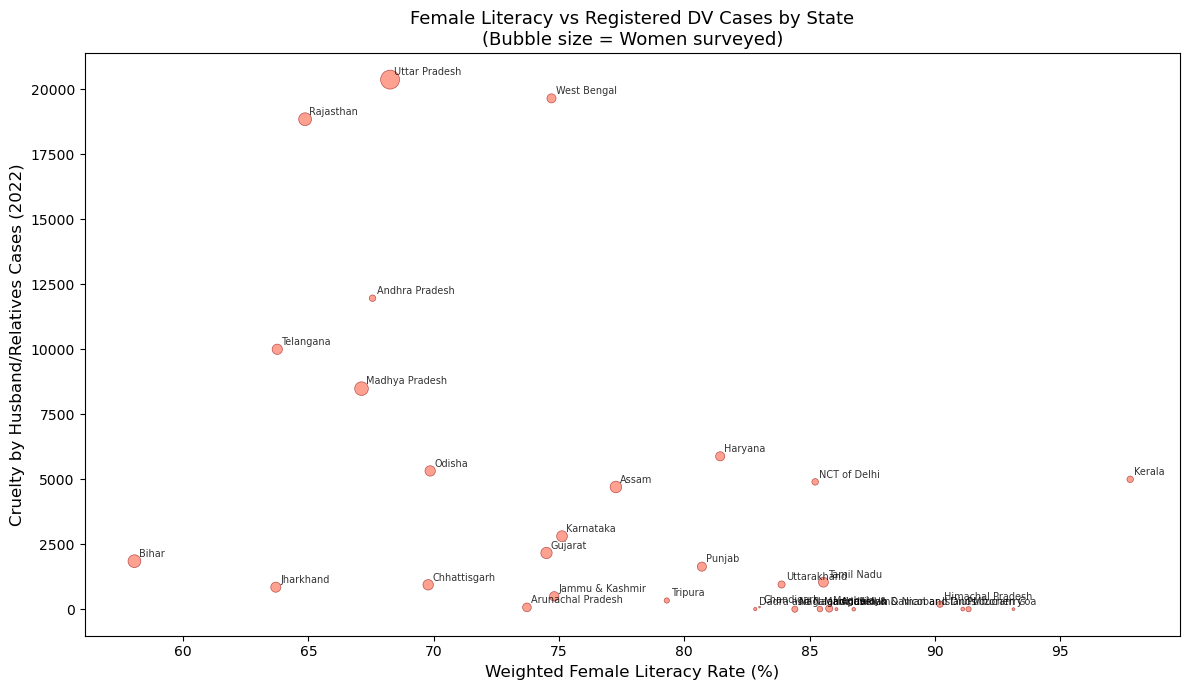

In [88]:
# Scatter plot — Literacy vs Cruelty Cases
plt.figure(figsize=(12, 7))

plt.scatter(merged['Weighted_Literacy'], 
            merged['Cruelty by Husband/relatives'],
            s=merged['Total_Women_Surveyed']/500,  # bubble size = population
            alpha=0.6,
            color='tomato',
            edgecolors='darkred',
            linewidth=0.5)

# Label each state
for _, row in merged.iterrows():
    plt.annotate(row['State/UT'], 
                xy=(row['Weighted_Literacy'], row['Cruelty by Husband/relatives']),
                fontsize=7,
                alpha=0.8,
                xytext=(3, 3),
                textcoords='offset points')

plt.xlabel('Weighted Female Literacy Rate (%)', fontsize=12)
plt.ylabel('Cruelty by Husband/Relatives Cases (2022)', fontsize=12)
plt.title('Female Literacy vs Registered DV Cases by State\n(Bubble size = Women surveyed)', fontsize=13)
plt.tight_layout()
plt.show()

In [89]:
merged['Cruelty_per_Lakh'] = (
    merged['Cruelty by Husband/relatives'] / 
    merged['Total_Women_Surveyed'] * 100000
).round(1)

# Top 10 states by rate
print("=== TOP 10 STATES BY CRUELTY RATE PER LAKH WOMEN ===")
print(merged[['State/UT', 'Weighted_Literacy', 'Cruelty_per_Lakh']]
      .sort_values('Cruelty_per_Lakh', ascending=False)
      .head(10)
      .to_string(index=False))

print()
print("=== BOTTOM 10 STATES BY CRUELTY RATE PER LAKH WOMEN ===")
print(merged[['State/UT', 'Weighted_Literacy', 'Cruelty_per_Lakh']]
      .sort_values('Cruelty_per_Lakh', ascending=True)
      .head(10)
      .to_string(index=False))

=== TOP 10 STATES BY CRUELTY RATE PER LAKH WOMEN ===
      State/UT  Weighted_Literacy  Cruelty_per_Lakh
Andhra Pradesh              67.56          109011.4
   West Bengal              74.70           91788.1
        Kerala              97.79           45564.8
  NCT of Delhi              85.22           43919.7
     Rajasthan              64.87           43840.4
     Telangana              63.76           36339.9
       Haryana              81.43           26852.0
 Uttar Pradesh              68.26           21875.1
        Odisha              69.86           19026.8
Madhya Pradesh              67.12           17529.4

=== BOTTOM 10 STATES BY CRUELTY RATE PER LAKH WOMEN ===
                              State/UT  Weighted_Literacy  Cruelty_per_Lakh
                              Nagaland              84.41              30.9
                               Mizoram              91.34              56.0
                                Sikkim              86.76              61.1
              

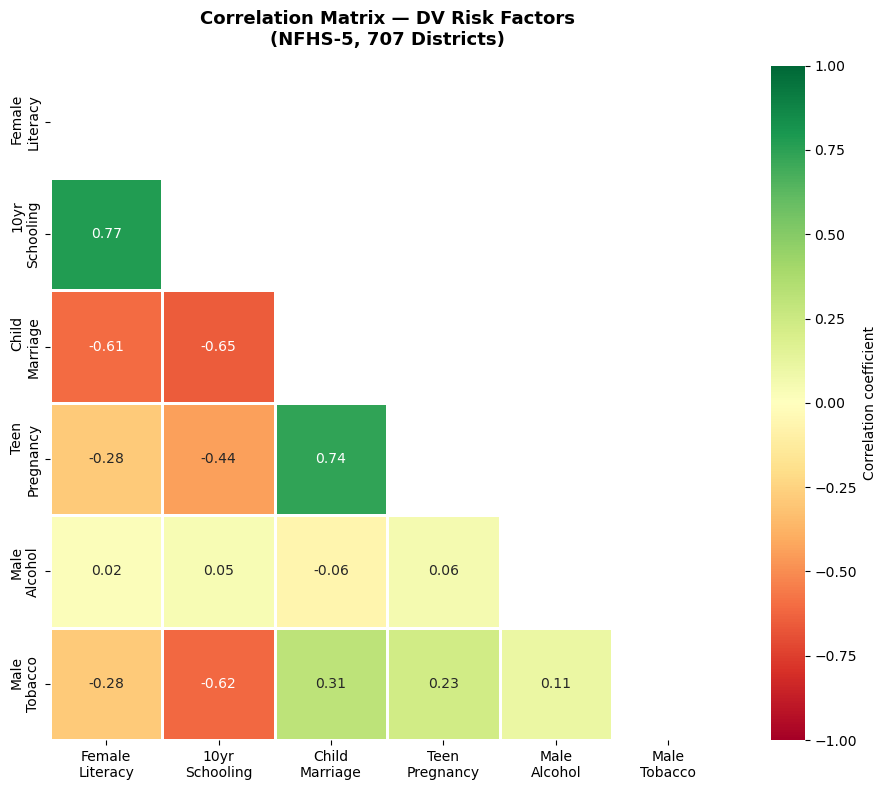

In [91]:
# Correlation Heatmap — all NFHS variables
cols = ['Literacy', 'Schooling_10yr', 'Child_Marriage', 
        'Teen_Pregnancy', 'Male_Alcohol', 'Male_Tobacco']

# Rename for cleaner labels on chart
corr_df = df[cols].copy()
corr_df.columns = ['Female\nLiteracy', '10yr\nSchooling', 
                   'Child\nMarriage', 'Teen\nPregnancy', 
                   'Male\nAlcohol', 'Male\nTobacco']

corr_matrix = corr_df.corr()

plt.figure(figsize=(10, 8))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True  # hide upper triangle — removes duplicates

sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            vmin=-1, vmax=1,
            linewidths=1,
            square=True,
            cbar_kws={'label': 'Correlation coefficient'})

plt.title('Correlation Matrix — DV Risk Factors\n(NFHS-5, 707 Districts)', 
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

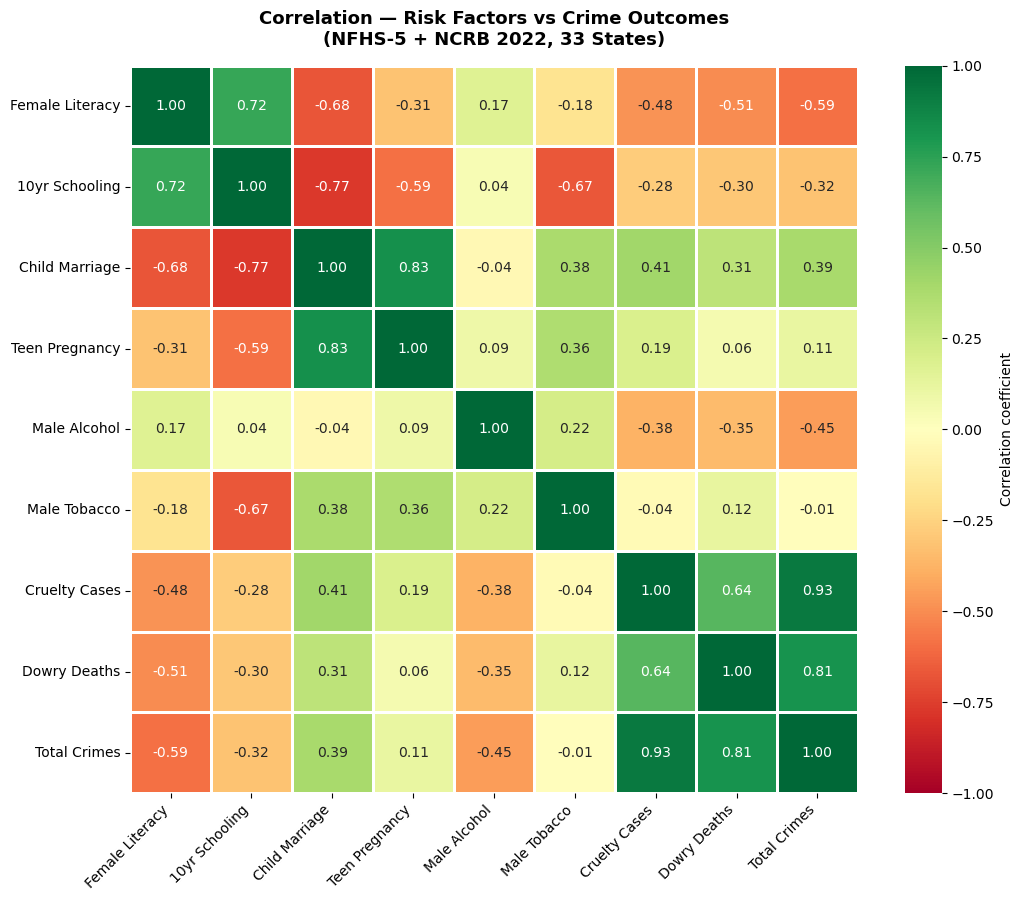

,Female Literacy,10yr Schooling,Child Marriage,Teen Pregnancy,Male Alcohol,Male Tobacco,Cruelty Cases,Dowry Deaths,Total Crimes
Female Literacy,1.000000,0.719677,-0.678902,-0.314266,0.165885,-0.178381,-0.483520,-0.505055,-0.586949
10yr Schooling,0.719677,1.000000,-0.766148,-0.593396,0.043097,-0.669167,-0.277581,-0.297299,-0.319932
Child Marriage,-0.678902,-0.766148,1.000000,0.832208,-0.040152,0.375688,0.406273,0.311238,0.389715
Teen Pregnancy,-0.314266,-0.593396,0.832208,1.000000,0.090800,0.364965,0.194475,0.056604,0.113646
Male Alcohol,0.165885,0.043097,-0.040152,0.090800,1.000000,0.218292,-0.381870,-0.349017,-0.446054
Male Tobacco,-0.178381,-0.669167,0.375688,0.364965,0.218292,1.000000,-0.035838,0.123083,-0.013820
Cruelty Cases,-0.483520,-0.277581,0.406273,0.194475,-0.381870,-0.035838,1.000000,0.636590,0.929571
Dowry Deaths,-0.505055,-0.297299,0.311238,0.056604,-0.349017,0.123083,0.636590,1.000000,0.813543
Total Crimes,-0.586949,-0.319932,0.389715,0.113646,-0.446054,-0.013820,0.929571,0.813543,1.000000


In [94]:
# Correlation heatmap — risk factors vs crime outcomes

# Select relevant columns from merged dataframe
heatmap_df = merged[['Weighted_Literacy',
                      'Weighted_Schooling_10yr', 
                      'Weighted_ChildMarriage',
                      'Weighted_TeenPregnancy',
                      'Weighted_MaleAlcohol',
                      'Weighted_MaleTobacco',
                      'Cruelty by Husband/relatives',
                      'Dowry Deaths',
                      'Total Crime against Women (IPC &SLL)']].copy()

# Rename for cleaner labels
heatmap_df.columns = ['Female Literacy', '10yr Schooling', 
                      'Child Marriage', 'Teen Pregnancy',
                      'Male Alcohol', 'Male Tobacco',
                      'Cruelty Cases', 'Dowry Deaths', 
                      'Total Crimes']

corr_matrix = heatmap_df.corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            vmin=-1, vmax=1,
            linewidths=0.8,
            square=True,
            cbar_kws={'label': 'Correlation coefficient'})

plt.title('Correlation — Risk Factors vs Crime Outcomes\n(NFHS-5 + NCRB 2022, 33 States)', 
          fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
corr_matrix

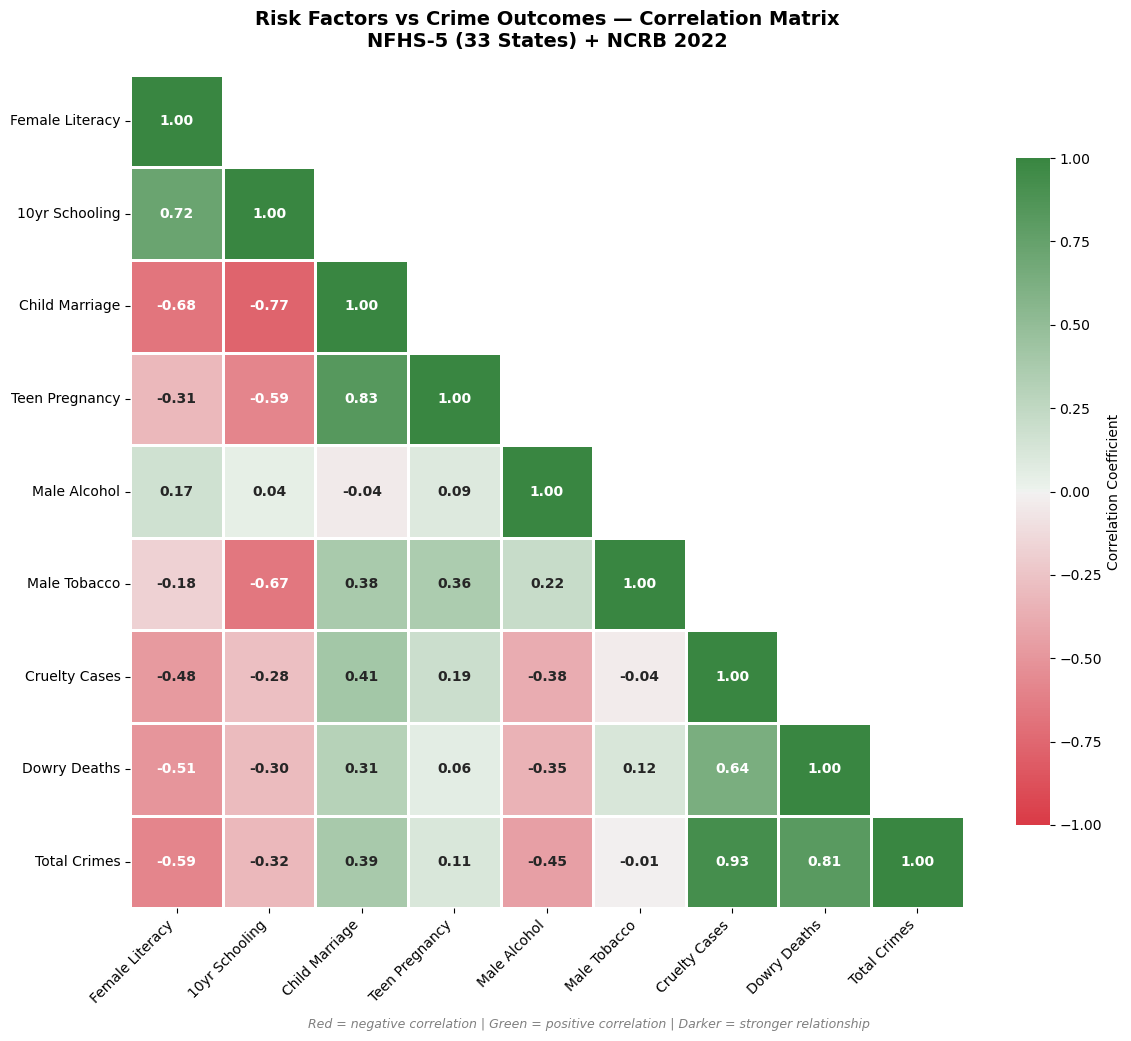

In [95]:
# Beautiful correlation heatmap
fig, ax = plt.subplots(figsize=(12, 10))

# Create diverging colormap
cmap = sns.diverging_palette(10, 130, as_cmap=True)

# Plot with mask for upper triangle
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap=cmap,
            vmin=-1, vmax=1,
            linewidths=0.8,
            square=True,
            mask=mask,
            annot_kws={'size': 10, 'weight': 'bold'},
            cbar_kws={'label': 'Correlation Coefficient', 
                      'shrink': 0.8})

# Add title and labels
ax.set_title('Risk Factors vs Crime Outcomes — Correlation Matrix\n'
             'NFHS-5 (33 States) + NCRB 2022', 
             fontsize=14, fontweight='bold', pad=20)

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

# Add annotation explaining the finding
fig.text(0.5, -0.02, 
         'Red = negative correlation | Green = positive correlation | '
         'Darker = stronger relationship',
         ha='center', fontsize=9, style='italic', color='gray')

plt.tight_layout()
plt.show()


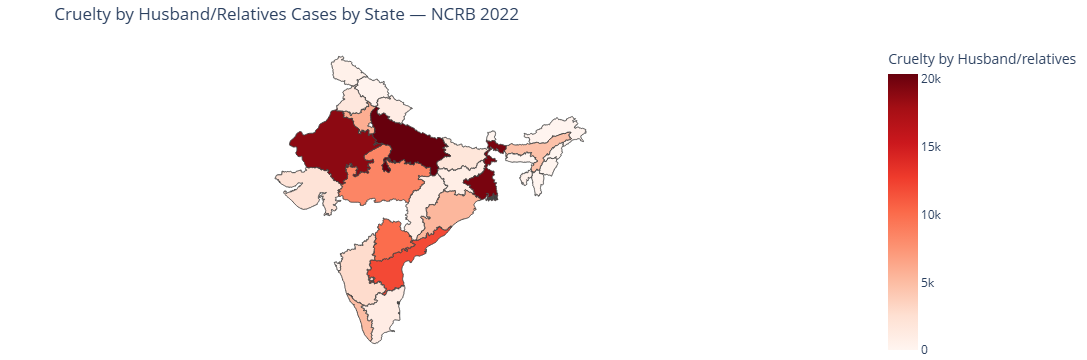

In [107]:
import plotly.express as px

# Use merged data we already have — 33 states is fine
fig = px.choropleth(
    merged,
    geojson="https://gist.githubusercontent.com/jbrobst/56c13bbbf9d97d187fea01ca62ea5112/raw/e388c4cae20aa53cb5090210a42ebb9b765c0a36/india_states.geojson",
    featureidkey='properties.ST_NM',
    locations='State/UT',
    color='Cruelty by Husband/relatives',
    color_continuous_scale='Reds',
    title='Cruelty by Husband/Relatives Cases by State — NCRB 2022'
)

fig.update_geos(fitbounds="locations", visible=False)
fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
fig.show()

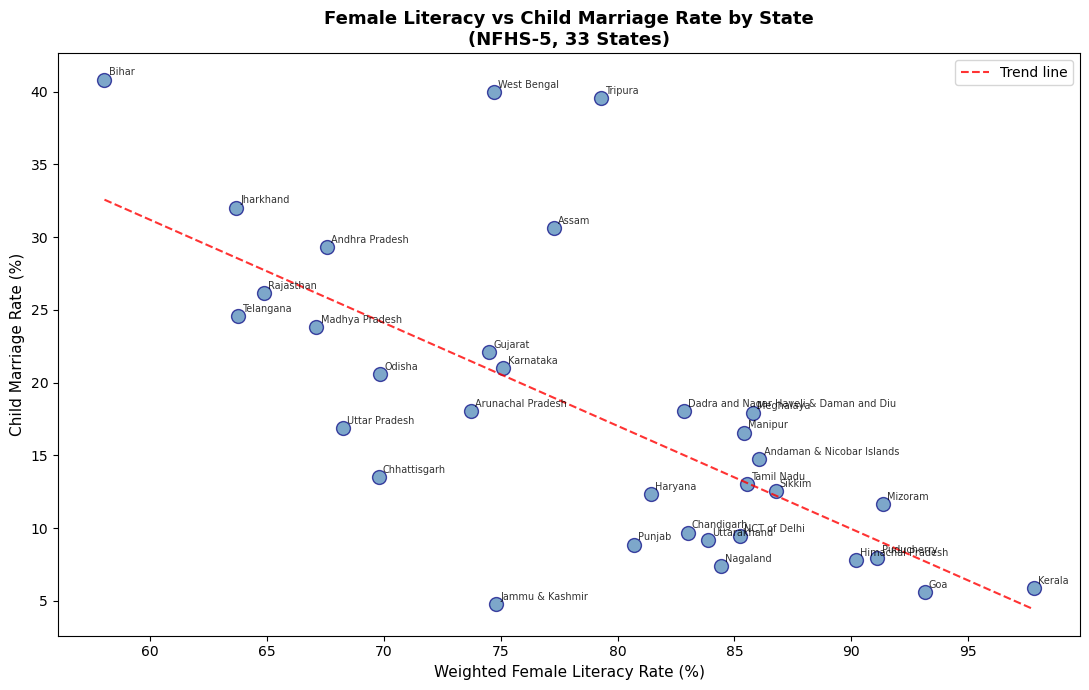

In [109]:
plt.figure(figsize=(11, 7))

plt.scatter(merged['Weighted_Literacy'],
            merged['Weighted_ChildMarriage'],
            s=100, color='steelblue', 
            edgecolors='navy', alpha=0.7)

# Label each state
for _, row in merged.iterrows():
    plt.annotate(row['State/UT'],
                xy=(row['Weighted_Literacy'], row['Weighted_ChildMarriage']),
                fontsize=7, alpha=0.8,
                xytext=(3, 3), textcoords='offset points')

# Add trend line
z = np.polyfit(merged['Weighted_Literacy'].dropna(), 
               merged['Weighted_ChildMarriage'].dropna(), 1)
p = np.poly1d(z)
x_line = np.linspace(merged['Weighted_Literacy'].min(), 
                     merged['Weighted_Literacy'].max(), 100)
plt.plot(x_line, p(x_line), 'r--', alpha=0.8, label='Trend line')

plt.xlabel('Weighted Female Literacy Rate (%)', fontsize=11)
plt.ylabel('Child Marriage Rate (%)', fontsize=11)
plt.title('Female Literacy vs Child Marriage Rate by State\n(NFHS-5, 33 States)', 
          fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()

plt.show()

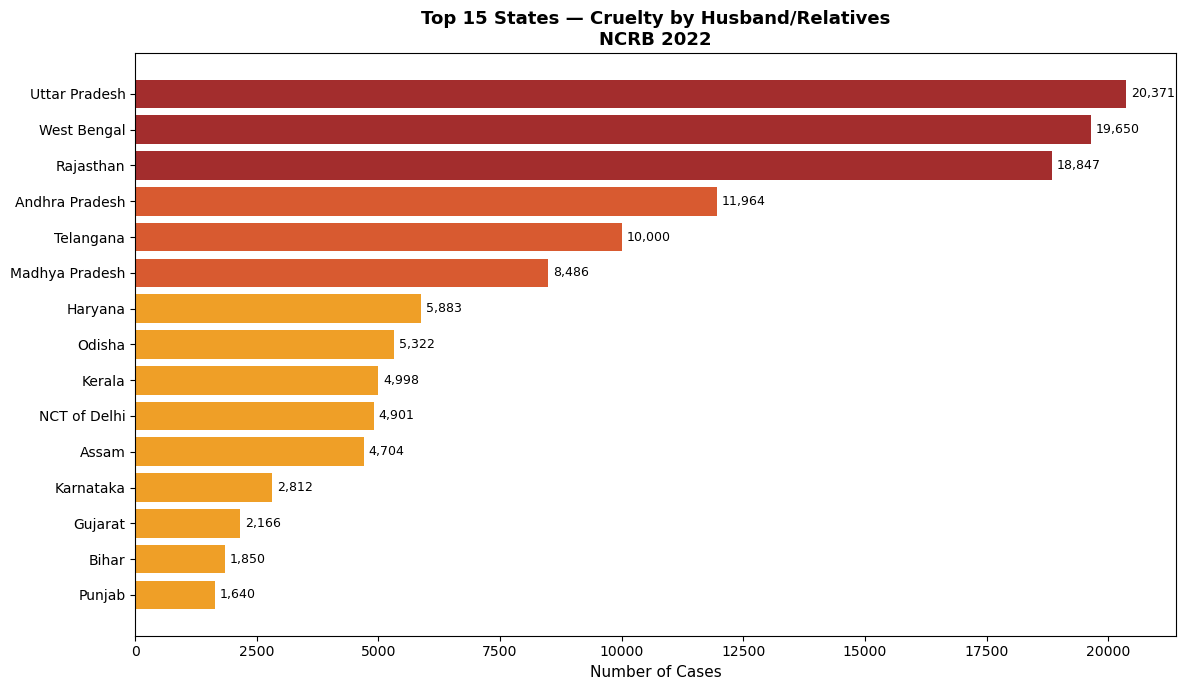

In [111]:
# Top 15 states by cruelty cases
top15 = merged.nlargest(15, 'Cruelty by Husband/relatives')

plt.figure(figsize=(12, 7))
bars = plt.barh(top15['State/UT'], 
                top15['Cruelty by Husband/relatives'],
                color=['#A32D2D' if x > 15000 
                       else '#D85A30' if x > 8000 
                       else '#EF9F27' for x in top15['Cruelty by Husband/relatives']])

for i, v in enumerate(top15['Cruelty by Husband/relatives']):
    plt.text(v + 100, i, f'{v:,}', va='center', fontsize=9)

plt.xlabel('Number of Cases', fontsize=11)
plt.title('Top 15 States — Cruelty by Husband/Relatives\nNCRB 2022', 
          fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

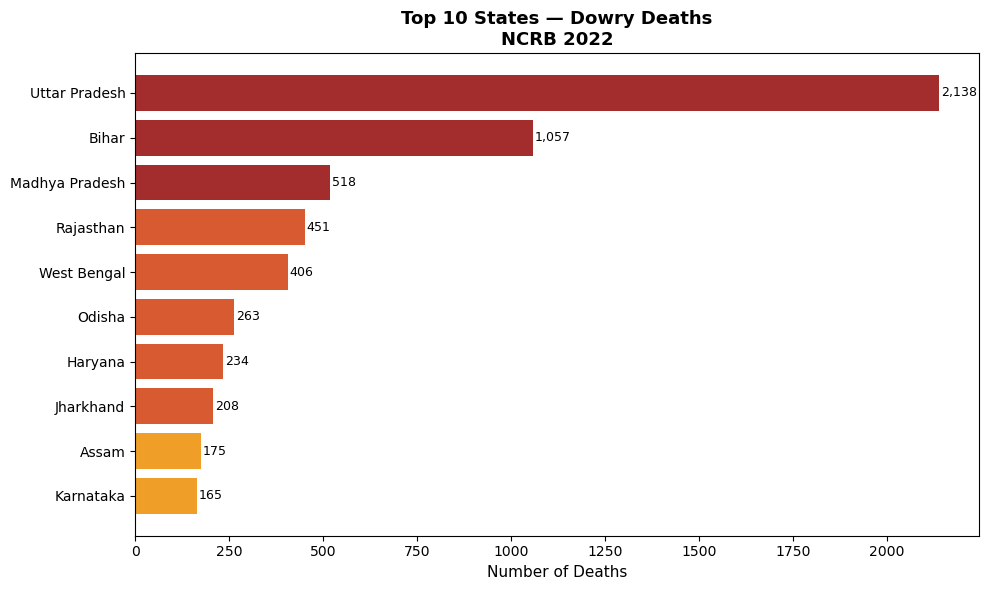

In [112]:
# Top 10 states by dowry deaths
top10_dowry = merged.nlargest(10, 'Dowry Deaths')

plt.figure(figsize=(10, 6))
plt.barh(top10_dowry['State/UT'],
         top10_dowry['Dowry Deaths'],
         color=['#A32D2D' if x > 500 
                else '#D85A30' if x > 200 
                else '#EF9F27' for x in top10_dowry['Dowry Deaths']])

for i, v in enumerate(top10_dowry['Dowry Deaths']):
    plt.text(v + 5, i, f'{v:,}', va='center', fontsize=9)

plt.xlabel('Number of Deaths', fontsize=11)
plt.title('Top 10 States — Dowry Deaths\nNCRB 2022', 
          fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [115]:
features = ['Weighted_Literacy', 
            'Weighted_Schooling_10yr',
            'Weighted_ChildMarriage',
            'Weighted_TeenPregnancy', 
            'Weighted_MaleAlcohol',
            'Weighted_MaleTobacco']

X = merged[features].dropna()
states_clean = merged.loc[X.index, 'State/UT']

print("States for clustering:", len(X))

States for clustering: 33


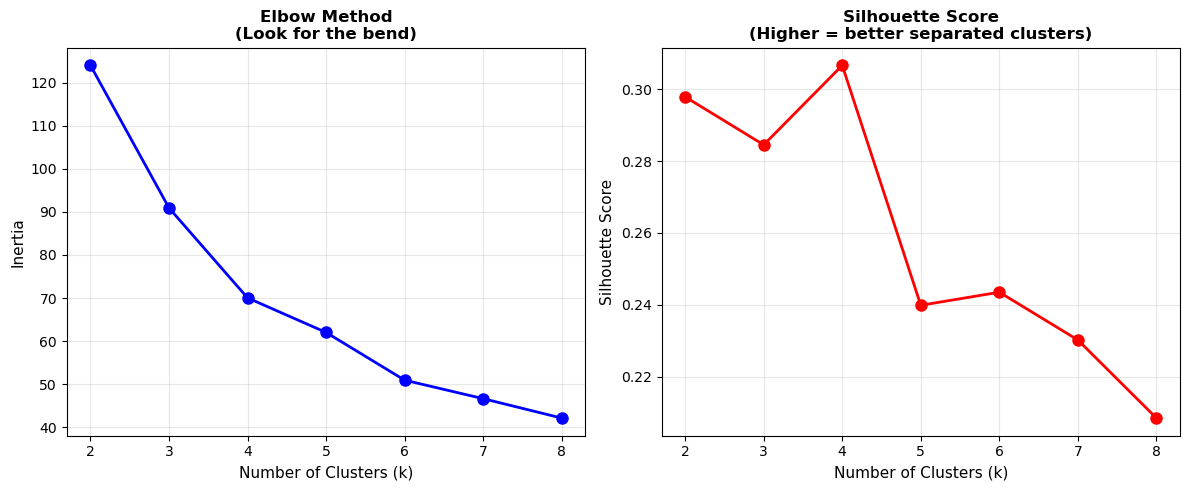

Inertia values: [124.0, 90.9, 70.0, 62.0, 51.0, 46.7, 42.2]
Silhouette scores: [0.298, 0.285, 0.307, 0.24, 0.243, 0.23, 0.208]


In [117]:
# Step 2 — Find optimal number of clusters using Elbow Method

# First normalize the data — IMPORTANT for clustering
# K-Means uses distance between points
# If literacy goes 0-100 and alcohol goes 0-50, alcohol gets less influence
# Scaling puts everything on equal footing

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Try k = 2 to 8 clusters and measure inertia
inertia = []
silhouette_scores = []
k_range = range(2, 9)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot elbow curve
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Elbow curve
axes[0].plot(k_range, inertia, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[0].set_ylabel('Inertia', fontsize=11)
axes[0].set_title('Elbow Method\n(Look for the bend)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Silhouette scores
axes[1].plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[1].set_ylabel('Silhouette Score', fontsize=11)
axes[1].set_title('Silhouette Score\n(Higher = better separated clusters)', 
                  fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Inertia values:", [round(x,1) for x in inertia])
print("Silhouette scores:", [round(x,3) for x in silhouette_scores])

In [118]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
merged['Cluster'] = kmeans.fit_predict(X_scaled)

# See which states are in each cluster
print("=== CLUSTER ASSIGNMENTS ===\n")
for cluster in sorted(merged['Cluster'].unique()):
    states = merged[merged['Cluster'] == cluster]['State/UT'].tolist()
    avg_literacy = merged[merged['Cluster'] == cluster]['Weighted_Literacy'].mean()
    avg_cm = merged[merged['Cluster'] == cluster]['Weighted_ChildMarriage'].mean()
    avg_cruelty = merged[merged['Cluster'] == cluster]['Cruelty by Husband/relatives'].mean()
    print(f"Cluster {cluster} — Avg Literacy: {avg_literacy:.1f}% | Avg Child Marriage: {avg_cm:.1f}% | Avg Cruelty Cases: {avg_cruelty:.0f}")
    for s in states:
        print(f"   → {s}")
    print()

=== CLUSTER ASSIGNMENTS ===

Cluster 0 — Avg Literacy: 70.8% | Avg Child Marriage: 19.1% | Avg Cruelty Cases: 8864
   → Gujarat
   → Jammu & Kashmir
   → Karnataka
   → Madhya Pradesh
   → Rajasthan
   → Uttar Pradesh

Cluster 1 — Avg Literacy: 80.0% | Avg Child Marriage: 16.0% | Avg Cruelty Cases: 1491
   → Andaman & Nicobar Islands
   → Arunachal Pradesh
   → Chhattisgarh
   → Dadra and Nagar Haveli & Daman and Diu
   → Manipur
   → Meghalaya
   → Mizoram
   → Nagaland
   → Odisha
   → Sikkim
   → Telangana

Cluster 2 — Avg Literacy: 70.1% | Avg Child Marriage: 35.4% | Avg Cruelty Cases: 6559
   → Andhra Pradesh
   → Assam
   → Bihar
   → Jharkhand
   → Tripura
   → West Bengal

Cluster 3 — Avg Literacy: 87.2% | Avg Child Marriage: 9.0% | Avg Cruelty Cases: 1971
   → Chandigarh
   → Goa
   → Haryana
   → Himachal Pradesh
   → Kerala
   → NCT of Delhi
   → Puducherry
   → Punjab
   → Tamil Nadu
   → Uttarakhand



In [121]:
# Rename clusters based on risk level
cluster_labels = {
    2: 'Extreme High Risk',
    0: 'High Risk',
    1: 'Medium Risk',
    3: 'Low Risk'
}

merged['Risk_Level'] = merged['Cluster'].map(cluster_labels)

# Verify
print(merged[['State/UT', 'Risk_Level', 'Weighted_Literacy', 
              'Weighted_ChildMarriage', 'Cruelty by Husband/relatives']]
      .sort_values('Risk_Level')
      .to_string(index=False))

                              State/UT        Risk_Level  Weighted_Literacy  Weighted_ChildMarriage  Cruelty by Husband/relatives
                           West Bengal Extreme High Risk              74.70                   39.98                         19650
                        Andhra Pradesh Extreme High Risk              67.56                   29.29                         11964
                                 Assam Extreme High Risk              77.27                   30.62                          4704
                                 Bihar Extreme High Risk              58.06                   40.82                          1850
                               Tripura Extreme High Risk              79.30                   39.54                           338
                             Jharkhand Extreme High Risk              63.70                   32.03                           850
                         Uttar Pradesh         High Risk              68.26               

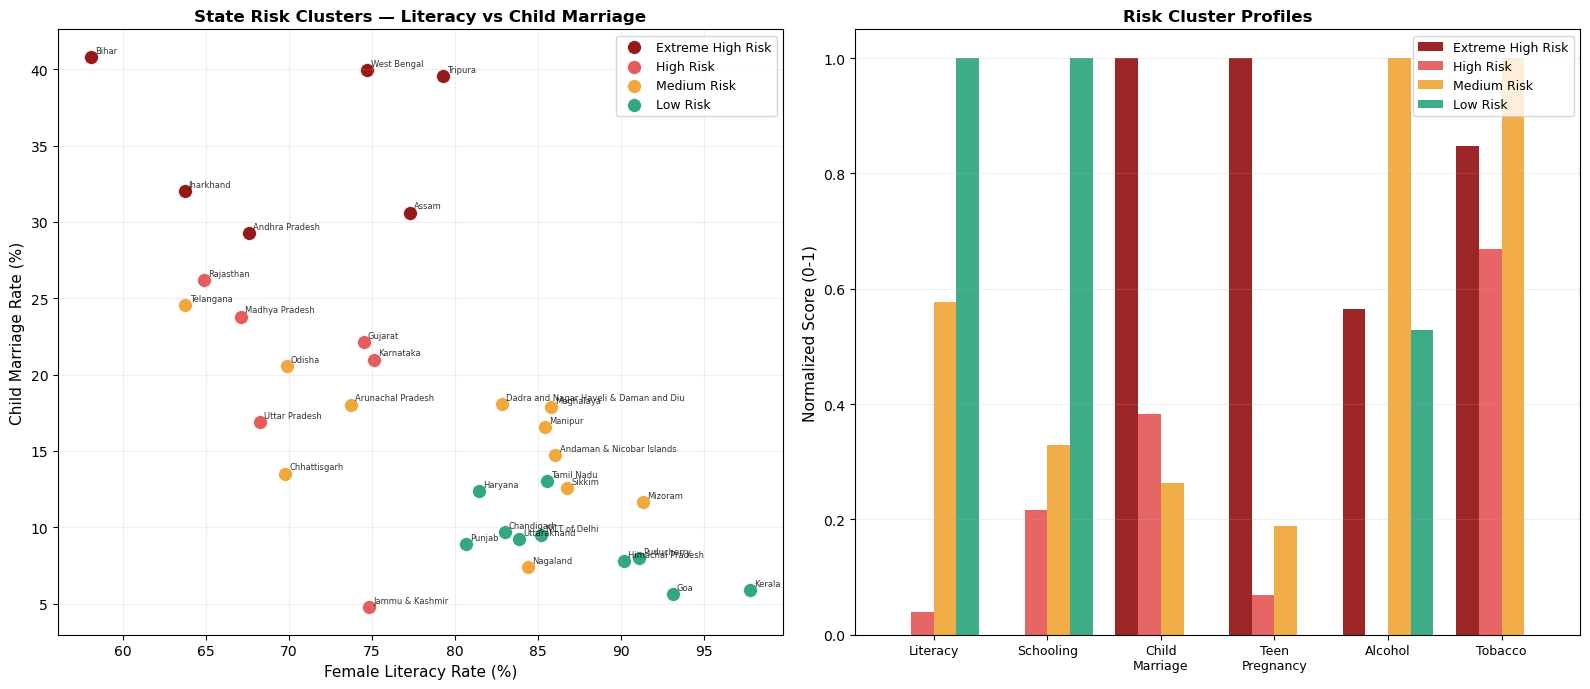

In [126]:
colors = {
    'Extreme High Risk' : '#8B0000',
    'High Risk'         : '#E24B4A',
    'Medium Risk'       : '#EF9F27',
    'Low Risk'          : '#1D9E75'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for risk in ['Extreme High Risk', 'High Risk', 'Medium Risk', 'Low Risk']:
    subset = merged[merged['Risk_Level'] == risk]
    axes[0].scatter(subset['Weighted_Literacy'],
                   subset['Weighted_ChildMarriage'],
                   c=colors[risk],
                   label=risk,
                   s=100, edgecolors='white',
                   linewidth=0.5, alpha=0.9)
    for _, row in subset.iterrows():
        axes[0].annotate(row['State/UT'],
                        xy=(row['Weighted_Literacy'],
                            row['Weighted_ChildMarriage']),
                        fontsize=6, alpha=0.8,
                        xytext=(3,3),
                        textcoords='offset points')

axes[0].set_xlabel('Female Literacy Rate (%)', fontsize=11)
axes[0].set_ylabel('Child Marriage Rate (%)', fontsize=11)
axes[0].set_title('State Risk Clusters — Literacy vs Child Marriage',
                  fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.2)

cluster_profiles = merged.groupby('Risk_Level')[features].mean()
cluster_profiles_norm = (cluster_profiles - cluster_profiles.min()) / \
                        (cluster_profiles.max() - cluster_profiles.min())

short_features = ['Literacy', 'Schooling', 'Child\nMarriage',
                  'Teen\nPregnancy', 'Alcohol', 'Tobacco']

x = np.arange(len(short_features))
width = 0.2
risk_order = ['Extreme High Risk', 'High Risk', 'Medium Risk', 'Low Risk']

for i, risk in enumerate(risk_order):
    axes[1].bar(x + i*width,
                cluster_profiles_norm.loc[risk],
                width,
                label=risk,
                color=colors[risk],
                alpha=0.85)

axes[1].set_xticks(x + width*1.5)
axes[1].set_xticklabels(short_features, fontsize=9)
axes[1].set_ylabel('Normalized Score (0-1)', fontsize=11)
axes[1].set_title('Risk Cluster Profiles',
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.2, axis='y')

plt.tight_layout()

plt.show()


In [127]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

labels = kmeans.labels_

print("=== K-MEANS EVALUATION ===")
print(f"Number of clusters: {kmeans.n_clusters}")
print(f"Inertia: {kmeans.inertia_:.2f}")

print(
    f"Silhouette Score: "
    f"{silhouette_score(X_scaled, labels):.3f}"
)

print(
    f"Davies-Bouldin Index: "
    f"{davies_bouldin_score(X_scaled, labels):.3f}"
)

print(
    f"Calinski-Harabasz Score: "
    f"{calinski_harabasz_score(X_scaled, labels):.2f}"
)

=== K-MEANS EVALUATION ===
Number of clusters: 4
Inertia: 70.05
Silhouette Score: 0.307
Davies-Bouldin Index: 1.047
Calinski-Harabasz Score: 17.66
